EDA — Credit Card Clients (Default / Late Payment Risk) by Kasia Mc art

In [62]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import random
import plotly.io as pio
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.express as px
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)


In [63]:
from sklearn.metrics import precision_recall_curve

In [64]:
import sys
print(sys.executable)

c:\Users\Kasia\AppData\Local\Programs\Python\Python311\python.exe


In [65]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


In [66]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

In [67]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [68]:
# ---------------------------------------------------------------------
# loading data
# ---------------------------------------------------------------------
def find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / ".git").exists():
            return parent
    return p

REPO_ROOT = find_repo_root()

In [69]:
# ---------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------
DATA_PATH = REPO_ROOT / "data" / "raw" / "default of credit card clients.xls"
SHEET_NAME = 0
RANDOM_STATE = 42

print("Repo root:", REPO_ROOT)
print("Data path:", DATA_PATH)
print("Exists:", DATA_PATH.exists())


Repo root: F:\Apps\Credit-Risk-Score-ML
Data path: F:\Apps\Credit-Risk-Score-ML\data\raw\default of credit card clients.xls
Exists: True


In [70]:
# ---------------------------------------------------------------------
# LOAD RAW DATA 
# ---------------------------------------------------------------------
df_raw = pd.read_excel(DATA_PATH, sheet_name=0, engine="xlrd", header=1)
print(df_raw.columns.tolist())
df_raw.head()

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [71]:
# -----------------------------------------------------------------------------
# HELPERS
# -----------------------------------------------------------------------------
def print_df(df: pd.DataFrame, name: str, n: int = 10):
    print("\n" + "-" * 95)
    print(f"[DATAFRAME] {name} | shape = {df.shape[0]:,} rows × {df.shape[1]:,} cols")
    print("-" * 95)
    print(df.head(n).to_string())

def section(title: str):
    print("\n" + "=" * 95)
    print(title)
    print("=" * 95)

def pct(x):
    return 100 * x


In [72]:
print(df_raw.columns.tolist())


['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [73]:
# =============================================================================
# CLEAN COLUMN NAMES
# =============================================================================
section("Cleaning column names")

df = df_raw.copy()

df = df.rename(columns={"default payment next month": "DEFAULT_NEXT_MONTH"})

if "ID" in df.columns:
    df["ID"] = df["ID"].astype(int)

print_df(df, "cleaned")
print("Target distribution (counts):")
print(df["DEFAULT_NEXT_MONTH"].value_counts(dropna=False).to_string())
print("\nTarget distribution (rate %):")
print((df["DEFAULT_NEXT_MONTH"].value_counts(normalize=True) * 100).round(2).to_string())



Cleaning column names

-----------------------------------------------------------------------------------------------
[DATAFRAME] cleaned | shape = 30,000 rows × 25 cols
-----------------------------------------------------------------------------------------------
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  DEFAULT_NEXT_MONTH
0   1      20000    2          2         1   24      2      2     -1     -1     -2     -2       3913       3102        689          0          0          0         0       689         0         0         0         0                   1
1   2     120000    2          2         2   26     -1      2      0      0      0      2       2682       1725       2682       3272       3455       3261         0      1000      1000      1000         0      2000                   1
2   3      90000    2   

## Data dictionary

**Target**
- `DEFAULT_NEXT_MONTH` — 1 = default next month, 0 = not default

**Static customer profile**
- `LIMIT_BAL` — credit limit
- `SEX`, `EDUCATION`, `MARRIAGE`, `AGE`

**Repayment status (behaviour)**
- `PAY_0`, `PAY_2`, `PAY_3`, `PAY_4`, `PAY_5`, `PAY_6`  
  (repayment status for the last 6 months; higher values = more delayed)

**Billing history**
- `BILL_AMT1` … `BILL_AMT6` — monthly statement balances

**Payment history**
- `PAY_AMT1` … `PAY_AMT6` — monthly payments made


In [74]:
# =============================================================================
# DATA QUALITY CHECKS
# =============================================================================
section("Data quality checks")

print("Missing values per column:")
na = df.isna().sum().sort_values(ascending=False)
print(na[na>0].to_string() if (na>0).any() else "No missing values found.")

# Duplicate ID check 
if "ID" in df.columns:
    dup = df["ID"].duplicated().sum()
    print(f"Duplicate IDs: {dup}")

section("describe() — numeric")
print(df.describe().T.to_string())



Data quality checks
Missing values per column:
No missing values found.
Duplicate IDs: 0

describe() — numeric
                      count           mean            std       min       25%       50%        75%        max
ID                  30000.0   15000.500000    8660.398374       1.0   7500.75   15000.5   22500.25    30000.0
LIMIT_BAL           30000.0  167484.322667  129747.661567   10000.0  50000.00  140000.0  240000.00  1000000.0
SEX                 30000.0       1.603733       0.489129       1.0      1.00       2.0       2.00        2.0
EDUCATION           30000.0       1.853133       0.790349       0.0      1.00       2.0       2.00        6.0
MARRIAGE            30000.0       1.551867       0.521970       0.0      1.00       2.0       2.00        3.0
AGE                 30000.0      35.485500       9.217904      21.0     28.00      34.0      41.00       79.0
PAY_0               30000.0      -0.016700       1.123802      -2.0     -1.00       0.0       0.00        8.0
PAY_2   

In [75]:
# =============================================================================
# TARGET DISTRIBUTION / CLASS IMBALANCE
# =============================================================================
section("Target distribution (class imbalance)")

target = "DEFAULT_NEXT_MONTH"
vc = df[target].value_counts(dropna=False).sort_index()
rate = df[target].mean()

print("Target counts:")
print(vc.to_string())
print(f"Default rate = {rate:.4f} ({rate*100:.2f}%)")

vc_df = vc.reset_index()
vc_df.columns = [target, "count"]

pio.templates.default = "plotly_white"   # set template before building figure

fig = px.bar(
    vc_df.assign(**{target: vc_df[target].astype(str)}),
    x=target,
    y="count",
    title="Target distribution (0=no default, 1=default)",
    color=target,
    color_discrete_map={"0": "#2E86AB", "1": "#D1495B"}
)
fig.update_layout(
    title_x=0.02,
    xaxis_title=target,
    yaxis_title="count",
    legend_title_text="Default"
)
fig.show()


Target distribution (class imbalance)
Target counts:
DEFAULT_NEXT_MONTH
0    23364
1     6636
Default rate = 0.2212 (22.12%)


In [76]:
# checking categorical variable distributions
# =============================================================================
# CATEGORICAL VARIABLES — DISTRIBUTIONS
# =============================================================================
section("Categorical variables distributions")

cat_cols = ["SEX", "EDUCATION", "MARRIAGE"]
for c in ["SEX", "EDUCATION", "MARRIAGE"]:
    print("\n" + "-" * 80)
    print(f"{c} value_counts:")
    print(df[c].value_counts(dropna=False).to_string())

    vc = df[c].value_counts(dropna=False).reset_index()
    vc.columns = [c, "count"]

    fig = px.bar(
        vc,
        x=c, y="count",
        title=f"{c} distribution",
        labels={c: c, "count": "count"}
    )
    fig.update_traces(marker_color=px.colors.qualitative.Set2)
    pio.templates.default = "plotly_white"
    fig.show()




Categorical variables distributions

--------------------------------------------------------------------------------
SEX value_counts:
SEX
2    18112
1    11888



--------------------------------------------------------------------------------
EDUCATION value_counts:
EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14



--------------------------------------------------------------------------------
MARRIAGE value_counts:
MARRIAGE
2    15964
1    13659
3      323
0       54


In [77]:
# checking data quality issues in EDUCATION column for values 0 and 6 which are not defined in the original dataset description
df[(df["EDUCATION"] == 0)]
#df[(df["EDUCATION"] == 6)]

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT_NEXT_MONTH
3769,3770,290000,2,0,2,38,1,-1,-1,-1,-1,-1,0,1437,3070,1406,2196,1481,1437,3078,1406,2196,1481,0,0
5945,5946,270000,1,0,2,39,1,-1,-1,-1,-1,-2,0,10193,69553,18607,0,0,10193,70213,19008,399,0,0,0
6876,6877,360000,1,0,2,30,0,0,-1,0,0,-1,40250,23022,12272,34345,36777,30,23000,12280,25007,25008,1767,3300,0
14631,14632,350000,2,0,2,53,-1,-1,-1,-1,-1,-1,5095,4815,61044,22611,1385,6043,4840,61349,22687,1389,6058,1153,0
15107,15108,210000,1,0,2,45,-2,-2,-2,-2,-2,-2,2563,5854,1032,788,3499,3372,5854,1032,788,3565,3372,15381,0
16881,16882,100000,1,0,2,37,0,0,-2,-2,-2,-2,7642,0,0,0,0,0,0,0,0,0,0,0,0
16896,16897,200000,1,0,2,40,1,-2,-1,-1,-1,-2,0,0,200,1000,0,0,0,200,1000,0,0,0,0
17414,17415,230000,2,0,2,47,-1,-1,-1,2,-1,-1,8394,5743,1336,255,5425,4838,5743,1598,0,5425,4838,3840,0
19920,19921,50000,2,0,1,40,0,0,0,0,0,0,44749,46229,46798,47647,40500,41921,2229,2298,2100,2500,1921,8432,0
20030,20031,200000,2,0,2,30,-1,-1,2,-1,-1,-1,17160,7289,2868,9470,5816,7809,2880,0,9470,5834,7809,2886,0


In [78]:
# checking numeric variable distributions and outliers with histograms and boxplots
# =============================================================================
# NUMERIC VARIABLES — DISTRIBUTIONS
# =============================================================================
section("Numeric variables distributions")

num_cols = ["LIMIT_BAL", "AGE"]
colors = ["steelblue", "indianred"]
for c, col in zip(num_cols, colors):
    fig = px.histogram(df, x=c, nbins=50, title=f"{c} — histogram")
    fig.update_traces(marker_color=col)
    fig.update_layout(bargap=0.15)
    fig.show()

fig = px.box(df, y="LIMIT_BAL", title="LIMIT_BAL — boxplot")
fig.update_traces(marker_color="steelblue")       # <- only one color line
fig.show()

fig = px.box(df, y="AGE", title="AGE — boxplot")
fig.update_traces(marker_color="indianred")       # <- only one color line
fig.show()



Numeric variables distributions


Investigating limit for customers over 0.5m, there are some that default it in payment and the data looks correct.

In [79]:
# checking outliers if they are real or data errors
high_limit1 = df[df["LIMIT_BAL"] > 800000]
high_limit2 = df[df["LIMIT_BAL"] > 500000]

high_limit1

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT_NEXT_MONTH
2197,2198,1000000,2,1,1,47,0,0,0,-1,0,0,964511,983931,535020,891586,927171,961664,50784,50723,896040,50000,50000,50256,0


In [80]:
high_limit2

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT_NEXT_MONTH
12,13,630000,2,2,2,41,-1,0,-1,-1,-1,-1,12137,6500,6500,6500,6500,2870,1000,6500,6500,6500,2870,0,0
260,261,510000,2,1,2,29,0,0,0,0,0,0,78331,99414,107686,103776,87265,36739,40010,20094,5000,5001,25365,65000,0
433,434,580000,2,1,1,36,0,0,0,0,0,0,159760,162189,166127,169365,168755,167964,6422,6565,5951,6006,5894,5946,0
451,452,600000,1,1,1,53,2,2,0,0,0,0,467150,458862,469703,447130,440982,434715,0,18000,16000,16000,21000,20000,1
527,528,620000,2,2,1,45,2,2,0,0,0,0,160837,156839,160440,163781,167159,170894,0,6200,6000,6000,6500,6000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29571,29572,570000,1,1,2,33,0,0,0,0,0,-2,388897,253793,261176,266800,0,0,9083,11472,12000,0,0,0,0
29740,29741,620000,1,2,2,31,-2,-2,-2,-2,-2,-2,5712,11598,21049,13846,3565,7076,11881,21171,13915,3583,7111,1971,0
29861,29862,650000,1,1,1,44,-2,-2,-2,-2,-2,-2,2119,5094,5158,7139,1034,2127,5115,5180,7201,1035,2139,3463,0
29886,29887,630000,1,2,1,46,0,0,0,0,0,0,125975,91247,81317,146005,146207,106467,3416,4300,84700,4211,4470,3600,0


this customer is real outlier 
LIMIT_BAL = 1,000,000
BILL_AMT ~ 900k–980k in several months
Some PAY_AMT are small (50k)
One PAY_AMT3 = 896,040 (very large)
but still fit into the repayments - no delay history

In [81]:
# =============================================================================
# TARGET vs FEATURES 
# =============================================================================
# checking default rate by categories of key features 
# calculating default rate by categories of key features to identify which features are most predictive 
# of the target variable and to gain insights into the relationships between features and default risk. 

section("Target rate by categories")

pay_cols = ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]

for c in pay_cols:
    print("\n" + "-"*80)
    print(f"{c} value_counts (top):")
    print(df[c].value_counts(dropna=False).head(12).to_string())

    g = df.groupby(c)["DEFAULT_NEXT_MONTH"].agg(count="size", default_rate="mean").reset_index()
    g["default_rate_pct"] = (g["default_rate"] * 100).round(2)
    g = g.sort_values("default_rate_pct", ascending=False)

    print(f"\nDefault rate by {c}:")
    print(g.to_string(index=False))

    fig = px.bar(
    g.sort_values(c),
    x=c,
    y="default_rate_pct",
    color=c, 
    title=f"Default rate (%) by {c}",
    labels={"default_rate_pct": "default rate (%)"},
    template="plotly_white"
    )
    pio.templates.default = "plotly_white"
    fig.show()




Target rate by categories

--------------------------------------------------------------------------------
PAY_0 value_counts (top):
PAY_0
 0    14737
-1     5686
 1     3688
-2     2759
 2     2667
 3      322
 4       76
 5       26
 8       19
 6       11
 7        9

Default rate by PAY_0:
 PAY_0  count  default_rate  default_rate_pct
     7      9      0.777778             77.78
     3    322      0.757764             75.78
     2   2667      0.691414             69.14
     4     76      0.684211             68.42
     8     19      0.578947             57.89
     6     11      0.545455             54.55
     5     26      0.500000             50.00
     1   3688      0.339479             33.95
    -1   5686      0.167781             16.78
    -2   2759      0.132294             13.23
     0  14737      0.128113             12.81



--------------------------------------------------------------------------------
PAY_2 value_counts (top):
PAY_2
 0    15730
-1     6050
 2     3927
-2     3782
 3      326
 4       99
 1       28
 5       25
 7       20
 6       12
 8        1

Default rate by PAY_2:
 PAY_2  count  default_rate  default_rate_pct
     6     12      0.750000             75.00
     3    326      0.616564             61.66
     5     25      0.600000             60.00
     7     20      0.600000             60.00
     2   3927      0.556150             55.61
     4     99      0.505051             50.51
    -2   3782      0.182708             18.27
     1     28      0.178571             17.86
    -1   6050      0.159669             15.97
     0  15730      0.159123             15.91
     8      1      0.000000              0.00



--------------------------------------------------------------------------------
PAY_3 value_counts (top):
PAY_3
 0    15764
-1     5938
-2     4085
 2     3819
 3      240
 4       76
 7       27
 6       23
 5       21
 1        4
 8        3

Default rate by PAY_3:
 PAY_3  count  default_rate  default_rate_pct
     7     27      0.814815             81.48
     8      3      0.666667             66.67
     6     23      0.608696             60.87
     4     76      0.578947             57.89
     3    240      0.575000             57.50
     5     21      0.571429             57.14
     2   3819      0.515580             51.56
     1      4      0.250000             25.00
    -2   4085      0.185312             18.53
     0  15764      0.174512             17.45
    -1   5938      0.155945             15.59



--------------------------------------------------------------------------------
PAY_4 value_counts (top):
PAY_4
 0    16455
-1     5687
-2     4348
 2     3159
 3      180
 4       69
 7       58
 5       35
 6        5
 1        2
 8        2

Default rate by PAY_4:
 PAY_4  count  default_rate  default_rate_pct
     7     58      0.827586             82.76
     4     69      0.666667             66.67
     3    180      0.611111             61.11
     2   3159      0.523267             52.33
     5     35      0.514286             51.43
     8      2      0.500000             50.00
     1      2      0.500000             50.00
     6      5      0.400000             40.00
    -2   4348      0.192502             19.25
     0  16455      0.183288             18.33
    -1   5687      0.158959             15.90



--------------------------------------------------------------------------------
PAY_5 value_counts (top):
PAY_5
 0    16947
-1     5539
-2     4546
 2     2626
 3      178
 4       84
 7       58
 5       17
 6        4
 8        1

Default rate by PAY_5:
 PAY_5  count  default_rate  default_rate_pct
     8      1      1.000000            100.00
     7     58      0.827586             82.76
     6      4      0.750000             75.00
     3    178      0.634831             63.48
     4     84      0.607143             60.71
     5     17      0.588235             58.82
     2   2626      0.541889             54.19
    -2   4546      0.196876             19.69
     0  16947      0.188529             18.85
    -1   5539      0.161943             16.19



--------------------------------------------------------------------------------
PAY_6 value_counts (top):
PAY_6
 0    16286
-1     5740
-2     4895
 2     2766
 3      184
 4       49
 7       46
 6       19
 5       13
 8        2

Default rate by PAY_6:
 PAY_6  count  default_rate  default_rate_pct
     8      2      1.000000            100.00
     7     46      0.826087             82.61
     6     19      0.736842             73.68
     3    184      0.641304             64.13
     4     49      0.632653             63.27
     5     13      0.538462             53.85
     2   2766      0.506508             50.65
    -2   4895      0.200409             20.04
     0  16286      0.188444             18.84
    -1   5740      0.169861             16.99


In [82]:
# c reating a summary table for PAY_0 vs DEFAULT_NEXT_MONTH to show the default rate 
# by categories of PAY_0 feature which represents the repayment status in the previous month 
# and is likely to be a strong predictor of default risk. This table will help us understand 
# how default rates vary across different repayment statuses and identify which categories of PAY_0 are associated with higher default risk.

TARGET = "DEFAULT_NEXT_MONTH"

g = (
    df.groupby("PAY_0")[TARGET]
      .agg(count="size", default_rate="mean")
      .reset_index()
)

g["default_rate_pct"] = (g["default_rate"] * 100).round(2)

g = g.sort_values("PAY_0")

# Clean final table
table = g[["PAY_0", "count", "default_rate_pct"]]
table.columns = ["PAY_0 (Months Past Due)", "Number of Customers", "Default Rate (%)"]

styled_table = (
    table.style
    .background_gradient(subset=["Default Rate (%)"], cmap="Reds")
    .set_properties(**{
        "background-color": "white",
        "color": "black",
        "border-color": "black"
    })
)

styled_table

,PAY_0 (Months Past Due),Number of Customers,Default Rate (%)
0,-2,2759,13.230000
1,-1,5686,16.780000
2,0,14737,12.810000
3,1,3688,33.950000
4,2,2667,69.140000
5,3,322,75.780000
6,4,76,68.420000
7,5,26,50.000000
8,6,11,54.550000
9,7,9,77.780000


In [83]:
# PAY_0 has a wide range of values
# putting together everything over the repayment status in the first month (PAY_0) into bins: -2, -1, 0, 1, 2, 3, 4 
# to remove the imbalance and make it easier to analyse. We can treat all values of 4 or higher as a single category "4" since they represent increasingly severe delinquency.

df["PAY_0_BIN"] = df["PAY_0"].clip(lower=-2, upper=4)

In [84]:
print_df(df, "cleaned")


-----------------------------------------------------------------------------------------------
[DATAFRAME] cleaned | shape = 30,000 rows × 26 cols
-----------------------------------------------------------------------------------------------
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  DEFAULT_NEXT_MONTH  PAY_0_BIN
0   1      20000    2          2         1   24      2      2     -1     -1     -2     -2       3913       3102        689          0          0          0         0       689         0         0         0         0                   1          2
1   2     120000    2          2         2   26     -1      2      0      0      0      2       2682       1725       2682       3272       3455       3261         0      1000      1000      1000         0      2000                   1         -1
2   3      900

In [85]:
# checking the distinct values in the new binned PAY_0_BIN column to confirm the binning worked as expected
sorted(df["PAY_0_BIN"].unique())

[np.int64(-2),
 np.int64(-1),
 np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4)]

In [86]:

# =============================================================================
# ANALYSIS: PAY_0 
# =============================================================================
# PAY_0 is the repayment status in the first month (the most recent month). It has a wide range of values. 
# Creating code to analyse the distribution of PAY_0 and its relationship with default rate, both with exact values and binned.

section("PAY_0 analysis")
colors = (
    px.colors.qualitative.Set3 +
    px.colors.qualitative.Dark24
)
pay_col = "PAY_0"

print("\n" + "-" * 80)
print(f"{pay_col} value_counts (top):")
print(df[pay_col].value_counts(dropna=False).head(15).to_string())

# 2) Default rate by exact PAY_0
g_exact = (
    df.groupby(pay_col)["DEFAULT_NEXT_MONTH"]
      .agg(count="size", default_rate="mean")
      .reset_index()
)
g_exact["default_rate_pct"] = (g_exact["default_rate"] * 100).round(2)
g_exact = g_exact.sort_values("default_rate_pct", ascending=False)

print("\nDefault rate by PAY_0 (exact):")
print(g_exact.to_string(index=False))

fig = px.bar(
    g_exact.sort_values(pay_col),
    x=pay_col,
    y="default_rate_pct",
    color=pay_col,
    color_discrete_sequence=colors,
    title="Default rate (%) by PAY_0 (exact values)",
    labels={"default_rate_pct": "default rate (%)"}
)
pio.templates.default = "plotly_white"
fig.show()

df["PAY_0_BIN"] = df[pay_col].clip(lower=-2, upper=4)
#df["PAY_0_BIN"] = df["PAY_0_BIN"].replace({4: "4"})

print("\nPAY_0_BIN value_counts:")
print(df["PAY_0_BIN"].value_counts(dropna=False).to_string())

g_bin = (
    df.groupby("PAY_0_BIN")["DEFAULT_NEXT_MONTH"]
      .agg(count="size", default_rate="mean")
      .reset_index()
)
g_bin["default_rate_pct"] = (g_bin["default_rate"] * 100).round(2)
g_bin = g_bin.sort_values("default_rate_pct", ascending=False)

print("\nDefault rate by PAY_0_BIN:")
print(g_bin.to_string(index=False))

fig = px.bar(
    g_bin,
    x="PAY_0_BIN", y="default_rate_pct",
    color="PAY_0_BIN",
    title="Default rate (%) by PAY_0_BIN (binned)",
    labels={"default_rate_pct": "default rate (%)"}
)
fig.update_traces(marker_color=px.colors.qualitative.Set2)
pio.templates.default = "plotly_white"
fig.show()

baseline = df["DEFAULT_NEXT_MONTH"].mean() * 100
print("\nBaseline default rate (%):", round(baseline, 2))

g_lift = g_bin.copy()
g_lift["lift_vs_baseline_x"] = (g_lift["default_rate_pct"] / baseline).round(2)
print("\nLift vs baseline (PAY_0_BIN):")
print(g_lift.sort_values("lift_vs_baseline_x", ascending=False).to_string(index=False))



PAY_0 analysis

--------------------------------------------------------------------------------
PAY_0 value_counts (top):
PAY_0
 0    14737
-1     5686
 1     3688
-2     2759
 2     2667
 3      322
 4       76
 5       26
 8       19
 6       11
 7        9

Default rate by PAY_0 (exact):
 PAY_0  count  default_rate  default_rate_pct
     7      9      0.777778             77.78
     3    322      0.757764             75.78
     2   2667      0.691414             69.14
     4     76      0.684211             68.42
     8     19      0.578947             57.89
     6     11      0.545455             54.55
     5     26      0.500000             50.00
     1   3688      0.339479             33.95
    -1   5686      0.167781             16.78
    -2   2759      0.132294             13.23
     0  14737      0.128113             12.81



PAY_0_BIN value_counts:
PAY_0_BIN
 0    14737
-1     5686
 1     3688
-2     2759
 2     2667
 3      322
 4      141

Default rate by PAY_0_BIN:
 PAY_0_BIN  count  default_rate  default_rate_pct
         3    322      0.757764             75.78
         2   2667      0.691414             69.14
         4    141      0.631206             63.12
         1   3688      0.339479             33.95
        -1   5686      0.167781             16.78
        -2   2759      0.132294             13.23
         0  14737      0.128113             12.81



Baseline default rate (%): 22.12

Lift vs baseline (PAY_0_BIN):
 PAY_0_BIN  count  default_rate  default_rate_pct  lift_vs_baseline_x
         3    322      0.757764             75.78                3.43
         2   2667      0.691414             69.14                3.13
         4    141      0.631206             63.12                2.85
         1   3688      0.339479             33.95                1.53
        -1   5686      0.167781             16.78                0.76
        -2   2759      0.132294             13.23                0.60
         0  14737      0.128113             12.81                0.58


Above default rate - 22% - means 22% missed the payment at least once. It is weighted average from all customers

Simple Interpretation

High Risk Groups

3 months late → 75.8% default rate
3.43× more likely to default than average
2 months late → 69.1% default rate
3.13× baseline risk
4+ months late → 63.1% default rate
2.85× baseline risk

extremely high-risk customers.

Medium Risk

1 month late → 33.9% default
1.53× baseline risk
Still higher than average.

Low Risk

On time (0) → 12.8% default
Only 0.58× baseline risk
Paid early (-1, -2) → 13–16%
0.60–0.76× baseline risk


In [87]:
# =============================================================================
# REPAYMENT STATUS 
# =============================================================================
section("Repayment status (PAY_*) overview")

pay_cols = ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]
for c in pay_cols:
    print("\n" + "-"*80)
    print(f"{c} value_counts (top):")
    print(df[c].value_counts().head(12).to_string())

# Default rate by each PAY_ * status
section("Default rate by PAY_0")
g = (df.groupby("PAY_0")["DEFAULT_NEXT_MONTH"]
       .agg(["count","mean"])
       .rename(columns={"mean":"default_rate"}))
g["default_rate_pct"] = (g["default_rate"]*100).round(2)
print(g.sort_values("default_rate", ascending=False).to_string())

fig = px.bar(g.reset_index(), x="PAY_0", y="default_rate_pct",
             title="Default rate (%) by PAY_0",
             labels={"default_rate_pct":"default rate (%)"},
             color="PAY_0",
             color_discrete_sequence=colors)
pio.templates.default = "plotly_white"
fig.show()



Repayment status (PAY_*) overview

--------------------------------------------------------------------------------
PAY_0 value_counts (top):
PAY_0
 0    14737
-1     5686
 1     3688
-2     2759
 2     2667
 3      322
 4       76
 5       26
 8       19
 6       11
 7        9

--------------------------------------------------------------------------------
PAY_2 value_counts (top):
PAY_2
 0    15730
-1     6050
 2     3927
-2     3782
 3      326
 4       99
 1       28
 5       25
 7       20
 6       12
 8        1

--------------------------------------------------------------------------------
PAY_3 value_counts (top):
PAY_3
 0    15764
-1     5938
-2     4085
 2     3819
 3      240
 4       76
 7       27
 6       23
 5       21
 1        4
 8        3

--------------------------------------------------------------------------------
PAY_4 value_counts (top):
PAY_4
 0    16455
-1     5687
-2     4348
 2     3159
 3      180
 4       69
 7       58
 5       35
 6        5
 1   

Distribution of Repayment Status (PAY_*)

Across PAY_0–PAY_6:

The majority of customers are PAY = 0 (paid on time)
A large group also have -1 or -2 (paid early / no delay)
Fewer customers are 2+ months late
Very small numbers are 5–8 months late

This shows:

Most customers are low risk, but a small delinquent group carries very high risk.

Default Rate by PAY_0 (Most Recent Month)

Baseline default rate: 22.12%

Groups:

1. Low Risk
PAY_0	Default Rate
0 (on time)	12.81%
-1	16.78%
-2	13.23%

2. Medium Risk
PAY_0	Default Rate
1 month late	33.95%

About 1.5× baseline risk.

3. Very High Risk
PAY_0	Default Rate
2 months late	69.14%
3 months late	75.78%
4 months late	68.42%
5+ months late	50–78%

These customers are:

3× more likely to default than average.

Key Insight

Default probability increases dramatically as delinquency increases.
The relationship is:

Strong
Monotonic (generally increasing)
Non-linear
Extremely predictive

This confirms that PAY_0 is a dominant risk variable.


Histograms — numeric variables before log transform


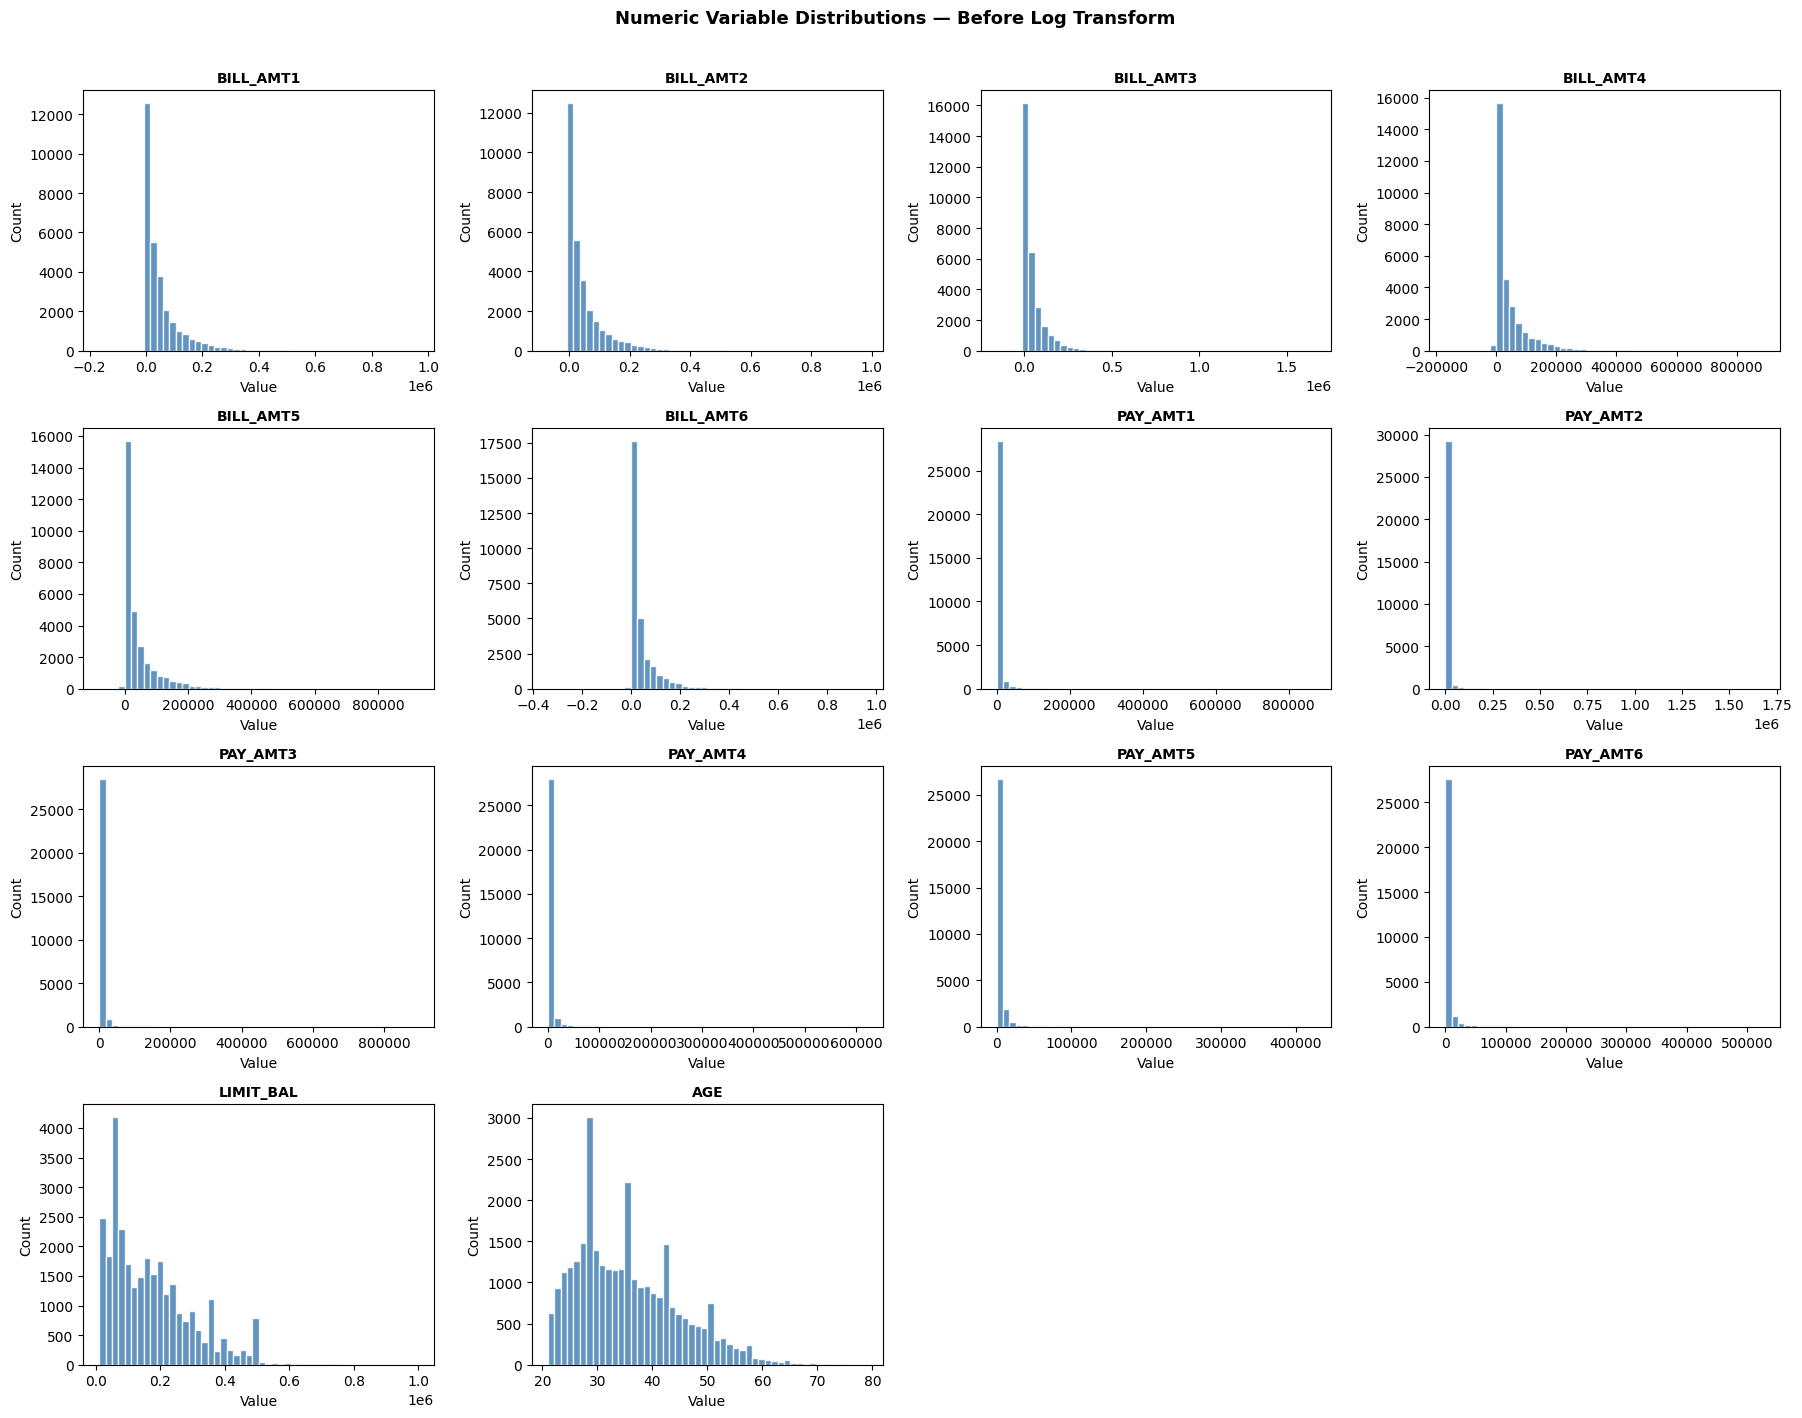

In [88]:
# =============================================================================
# HISTOGRAMS — NUMERIC VARIABLES BEFORE LOG TRANSFORM
# =============================================================================

section("Histograms — numeric variables before log transform")

import matplotlib.pyplot as plt
import numpy as np

bill_cols  = [f"BILL_AMT{i}" for i in range(1, 7)]
pay_cols   = [f"PAY_AMT{i}"  for i in range(1, 7)]
other_cols = ["LIMIT_BAL", "AGE"]

all_num_cols = bill_cols + pay_cols + other_cols

n_cols = 4
n_rows = int(np.ceil(len(all_num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(all_num_cols):
    axes[i].hist(df[col], bins=50, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Variable Distributions — Before Log Transform",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("histograms_before_log.png", dpi=150, bbox_inches="tight")
plt.show()

In [89]:
# =============================================================================
# BILLING / PAYMENTS — MONTHLY PATTERNS (mean / median)
# =============================================================================
# calculating mean and median for billing amounts and payment amounts over the last 6 months to 
# understand typical values and potential outliers, and how they evolve over time.

section("Billing and payments — monthly patterns")

bill_cols = [f"BILL_AMT{i}" for i in range(1,7)]
pay_amt_cols = [f"PAY_AMT{i}" for i in range(1,7)]

bill_stats = df[bill_cols].agg(["mean","median"]).T
pay_stats  = df[pay_amt_cols].agg(["mean","median"]).T

print("\nBilling stats (mean/median):")
print(bill_stats.to_string())
print("\nPayment stats (mean/median):")
print(pay_stats.to_string())

# Line charts
fig = go.Figure()
fig.add_trace(go.Scatter(x=bill_stats.index, y=bill_stats["mean"], mode="lines+markers", name="Bill mean"))
fig.add_trace(go.Scatter(x=bill_stats.index, y=bill_stats["median"], mode="lines+markers", name="Bill median"))
fig.update_layout(title="Billing amounts over last 6 months (mean vs median)", xaxis_title="month column", yaxis_title="amount")
pio.templates.default = "plotly_white"
fig.show()

fig = go.Figure()
fig.add_trace(go.Scatter(x=pay_stats.index, y=pay_stats["mean"], mode="lines+markers", name="Pay mean"))
fig.add_trace(go.Scatter(x=pay_stats.index, y=pay_stats["median"], mode="lines+markers", name="Pay median"))
fig.update_layout(title="Payment amounts over last 6 months (mean vs median)", xaxis_title="month column", yaxis_title="amount")
pio.templates.default = "plotly_white"
fig.show()



Billing and payments — monthly patterns

Billing stats (mean/median):
                   mean   median
BILL_AMT1  51223.330900  22381.5
BILL_AMT2  49179.075167  21200.0
BILL_AMT3  47013.154800  20088.5
BILL_AMT4  43262.948967  19052.0
BILL_AMT5  40311.400967  18104.5
BILL_AMT6  38871.760400  17071.0

Payment stats (mean/median):
                 mean  median
PAY_AMT1  5663.580500  2100.0
PAY_AMT2  5921.163500  2009.0
PAY_AMT3  5225.681500  1800.0
PAY_AMT4  4826.076867  1500.0
PAY_AMT5  4799.387633  1500.0
PAY_AMT6  5215.502567  1500.0


Billing Amounts (BILL_AMT1–6)

* **Mean > Median for all months**
* Bills gradually decrease from Month 1 to Month 6

Example:

 Month      Mean Bill  Median Bill 
 BILL_AMT1  51,223     22,381      
 BILL_AMT6  38,872     17,071      

**Strong right skew**

Since:
Mean >> Median
spending distribution is highly skewed.

**Bills trend downward slightly over 6 months**

The average bill decreases over time:

51k → 38k

This trend feature could be useful for:

* Risk slope features
* Behaviour change detection

Payment Amounts (PAY_AMT1–6)

### Key observations:

Month    | Mean Payment | Median Payment 

PAY_AMT1 | 5,663        | 2,100          
PAY_AMT6 | 5,215        | 1,500          

Again:

Mean >> Median

Strong skew.

Bills are large, skewed.
Payments are smaller and also skewed.


In [90]:

# =============================================================================
# CORRELATIONS 
# =============================================================================

# checking correlations between numeric features for Pearson and Spearman methods, 
# and quick top correlations with target to identify which features have the strongest linear and monotonic relationships with the target variable.

section("Correlation heatmap")

# Correlation can be dominated by outliers; also checking Spearman in addition to Pearson.
num_for_corr = df.drop(columns=["ID"], errors="ignore").select_dtypes(include=[np.number]).copy()

corr_pearson = num_for_corr.corr(method="pearson")
corr_spearman = num_for_corr.corr(method="spearman")

fig = px.imshow(corr_pearson, title="Correlation heatmap- Pearson", aspect="auto")
fig.show()

fig = px.imshow(corr_spearman, title="Correlation heatmap- Spearman", aspect="auto")
fig.show()

section("Top absolute correlations with target - Pearson")
target_corr = corr_pearson["DEFAULT_NEXT_MONTH"].drop("DEFAULT_NEXT_MONTH").abs().sort_values(ascending=False)
print(target_corr.head(20).to_string())

section("Top absolute correlations with target - Spearman")
target_corr = corr_spearman["DEFAULT_NEXT_MONTH"].drop("DEFAULT_NEXT_MONTH").abs().sort_values(ascending=False)
print(target_corr.head(20).to_string())



Correlation heatmap



Top absolute correlations with target - Pearson
PAY_0_BIN    0.328055
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
LIMIT_BAL    0.153520
PAY_AMT1     0.072929
PAY_AMT2     0.058579
PAY_AMT4     0.056827
PAY_AMT3     0.056250
PAY_AMT5     0.055124
PAY_AMT6     0.053183
SEX          0.039961
EDUCATION    0.028006
MARRIAGE     0.024339
BILL_AMT1    0.019644
BILL_AMT2    0.014193
BILL_AMT3    0.014076

Top absolute correlations with target - Spearman
PAY_0_BIN    0.292215
PAY_0        0.292213
PAY_2        0.216919
PAY_3        0.194771
PAY_4        0.173690
LIMIT_BAL    0.169586
PAY_AMT1     0.160493
PAY_5        0.159043
PAY_AMT2     0.150977
PAY_6        0.142523
PAY_AMT3     0.139388
PAY_AMT4     0.127979
PAY_AMT6     0.121444
PAY_AMT5     0.116587
EDUCATION    0.044369
SEX          0.039961
MARRIAGE     0.026490
BILL_AMT1    0.025327
BILL_AMT2    0.015554
BILL_AMT3    0.012670


These are **Pearson correlations** between each variable and the target:

`DEFAULT_NEXT_MONTH`

Strongest Predictors

Top correlations:

 PAY_0 - **0.325**   
 PAY_2 - 0.264       
 PAY_3 - 0.235       
 PAY_4 - 0.217       
 PAY_5 - 0.204       
 PAY_6 - 0.187       

### Interpretation:

PAY_0 alone has correlation ≈ 0.325 — which is very high for behavioural financial data.

The correlation decreases as we go further back in time (PAY_6).
More recent behaviour matters more.

# Moderate Predictors

 LIMIT_BAL- 0.154  
Credit limit has moderate correlation.

Pearson measures **linear relationship only**.

Tree-based models (LightGBM/XGBoost):

> Pearson correlation analysis indicates that repayment status variables (PAY_0–PAY_6) exhibit the strongest linear association with default, with PAY_0 showing the highest correlation (r = 0.325). However, given the ordinal nature of repayment variables and the presence of skewness in financial features, Spearman correlation provides a more appropriate measure of monotonic association. Both analyses confirm the dominant role of recent repayment behaviour in predicting default risk.

These are **Spearman correlations**
Strongest Predictors 

# Top variables:

PAY_0_BIN → 0.292
PAY_0 → 0.292
PAY_2 → 0.217
PAY_3 → 0.195
PAY_4 → 0.174

Repayment status variables remain the strongest predictors.
The monotonic association confirms that higher repayment delay corresponds to higher default likelihood.
Correlation strength decreases for older repayment months, recent behaviour matters most.

# Changes:

Payment amounts (PAY_AMT1–6)

Under Pearson → ~0.05–0.07 (weak)
Under Spearman → 0.12–0.16 (moderate)

Spearman captures monotonic patterns even if not linear.


In [91]:
# =============================================================================
# FEATURE ENGINEERING 
# =============================================================================

# in here we are trying some common feature engineering ideas for this dataset, especially around the billing and payment history which is often key for credit default prediction. 
# This includes creating payment ratio features, utilisation proxies, aggregates over time, and delinquency features based on the PAY_X columns.

section("Feature engineering")

df_fe = df.copy()
# cleaning and recoding categorical variables based on the original dataset description, some values in EDUCATION and MARRIAGE columns are not defined 
# in the original dataset description, grouping them into an "Other" category (4 for EDUCATION and 3 for MARRIAGE) 

# EDUCATION: 
df_fe["EDUCATION"] = df_fe["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
# MARRIAGE: 
df_fe["MARRIAGE"] = df_fe["MARRIAGE"].replace({0: 3})

# Creating Payment ratio columns which represent the ratio of payment amount to billed amount for each of the last 6 months. This can help capture how much of the billed amount the customer is paying each month, 
# which is a strong signal of credit risk. A low payment ratio may indicate financial distress, while a high payment ratio
bill_cols = [f"BILL_AMT{i}" for i in range(1,7)]
pay_cols_amt = [f"PAY_AMT{i}" for i in range(1,7)]

for i in range(1,7):
    b = f"BILL_AMT{i}"
    p = f"PAY_AMT{i}"
    df_fe[f"PAY_RATIO{i}"] = df_fe[p] / (df_fe[b].abs() + 1)  # +1 to avoid division by zero

#  Utilisation 

df_fe["UTILISATION6M_MEAN"] = (df_fe[bill_cols].clip(lower=0).mean(axis=1)) / (df_fe["LIMIT_BAL"] + 1)

# Aggregates over 6 months

df_fe["BILL_TOTAL_6M"] = df_fe[bill_cols].sum(axis=1)
df_fe["PAY_TOTAL_6M"]  = df_fe[pay_cols_amt].sum(axis=1)
df_fe["PAY_RATIO_6M_MEAN"] = df_fe[[f"PAY_RATIO{i}" for i in range(1,7)]].mean(axis=1)

print_df(df_fe, "with new features")


Feature engineering

-----------------------------------------------------------------------------------------------
[DATAFRAME] with new features | shape = 30,000 rows × 36 cols
-----------------------------------------------------------------------------------------------
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  DEFAULT_NEXT_MONTH  PAY_0_BIN  PAY_RATIO1  PAY_RATIO2  PAY_RATIO3    PAY_RATIO4  PAY_RATIO5  PAY_RATIO6  UTILISATION6M_MEAN  BILL_TOTAL_6M  PAY_TOTAL_6M  PAY_RATIO_6M_MEAN
0   1      20000    2          2         1   24      2      2     -1     -1     -2     -2       3913       3102        689          0          0          0         0       689         0         0         0         0                   1          2    0.000000    0.222043    0.000000      0.000000    0.000000    0.000000            0.0


Default rate by demographic variables


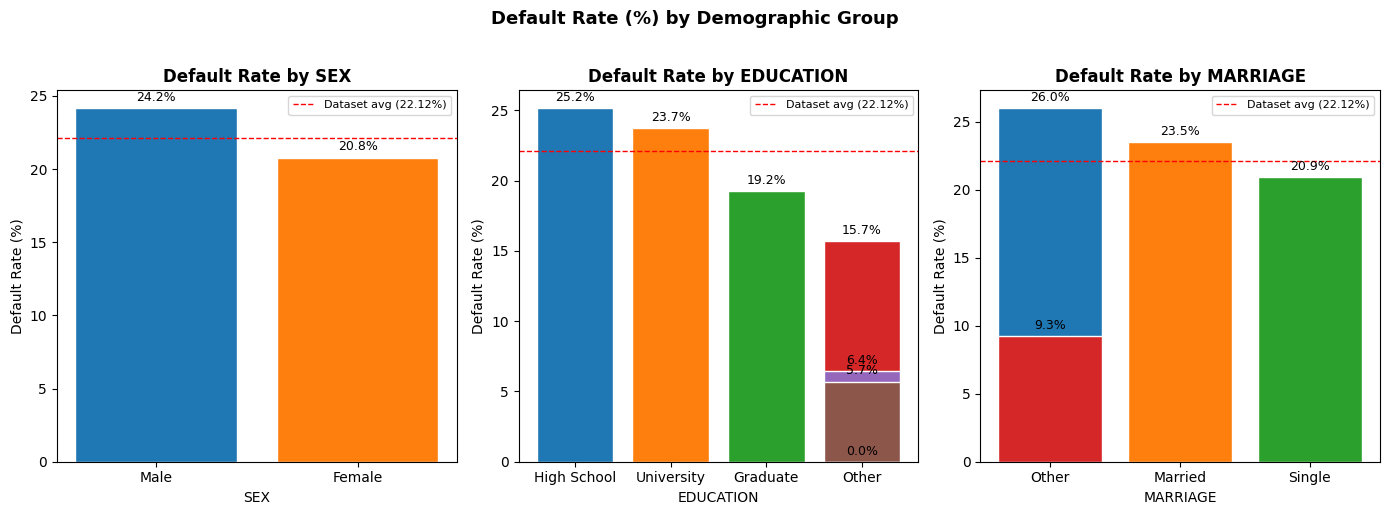

In [92]:
# =============================================================================
# DEFAULT RATE BY DEMOGRAPHIC VARIABLES
# =============================================================================
section("Default rate by demographic variables")

demo_cols = {
    "SEX":       {1: "Male", 2: "Female"},
    "EDUCATION": {1: "Graduate", 2: "University", 3: "High School", 4: "Other"},
    "MARRIAGE":  {1: "Married", 2: "Single", 3: "Other"}
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (col, label_map) in zip(axes, demo_cols.items()):
    g = (df.groupby(col)["DEFAULT_NEXT_MONTH"]
           .mean()
           .mul(100)
           .rename("default_rate_pct")
           .reset_index())
    g[col] = g[col].map(label_map).fillna("Other")
    g = g.sort_values("default_rate_pct", ascending=False)

    bars = ax.bar(g[col], g["default_rate_pct"], color=plt.cm.tab10.colors[:len(g)], edgecolor="white")
    ax.axhline(y=22.12, color="red", linestyle="--", linewidth=1, label="Dataset avg (22.12%)")
    ax.set_title(f"Default Rate by {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Default Rate (%)")
    ax.legend(fontsize=8)

    for bar, val in zip(bars, g["default_rate_pct"]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f"{val:.1f}%",
                ha="center", va="bottom", fontsize=9)

plt.suptitle("Default Rate (%) by Demographic Group", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("default_rate_by_demographics.png", dpi=150, bbox_inches="tight")
plt.show()

In [93]:
# =============================================================================
# LOG TRANSFORMS — skewed numeric variables
# Applied to LR-sensitive features to reduce skewness
# np.log1p used (log(1+x)) to handle zero values safely
# =============================================================================

section("Log transforms — skewed numeric variables")

import numpy as np

# PAY_AMT1-6 — heavily right skewed, large outliers
for i in range(1, 7):
    col = f"PAY_AMT{i}"
    df_fe[f"LOG_{col}"] = np.log1p(df_fe[col])
    print(f"LOG_{col} — original skew: {df_fe[col].skew():.2f} → log skew: {df_fe[f'LOG_{col}'].skew():.2f}")

# BILL_AMT1-6 — right skewed, can be negative
# clip at 0 first before log as log of negative is undefined
for i in range(1, 7):
    col = f"BILL_AMT{i}"
    df_fe[f"LOG_{col}"] = np.log1p(df_fe[col].clip(lower=0))
    print(f"LOG_{col} — original skew: {df_fe[col].skew():.2f} → log skew: {df_fe[f'LOG_{col}'].skew():.2f}")

# LIMIT_BAL — right skewed
df_fe["LOG_LIMIT_BAL"] = np.log1p(df_fe["LIMIT_BAL"])
print(f"LOG_LIMIT_BAL — original skew: {df_fe['LIMIT_BAL'].skew():.2f} → log skew: {df_fe['LOG_LIMIT_BAL'].skew():.2f}")

print(f"\nNew log features added: {[c for c in df_fe.columns if c.startswith('LOG_')]}")


Log transforms — skewed numeric variables
LOG_PAY_AMT1 — original skew: 14.67 → log skew: -1.29
LOG_PAY_AMT2 — original skew: 30.45 → log skew: -1.24
LOG_PAY_AMT3 — original skew: 17.22 → log skew: -1.08
LOG_PAY_AMT4 — original skew: 12.90 → log skew: -0.97
LOG_PAY_AMT5 — original skew: 11.13 → log skew: -0.94
LOG_PAY_AMT6 — original skew: 10.64 → log skew: -0.85
LOG_BILL_AMT1 — original skew: 2.66 → log skew: -1.72
LOG_BILL_AMT2 — original skew: 2.71 → log skew: -1.60
LOG_BILL_AMT3 — original skew: 3.09 → log skew: -1.54
LOG_BILL_AMT4 — original skew: 2.82 → log skew: -1.48
LOG_BILL_AMT5 — original skew: 2.88 → log skew: -1.40
LOG_BILL_AMT6 — original skew: 2.85 → log skew: -1.28
LOG_LIMIT_BAL — original skew: 0.99 → log skew: -0.51

New log features added: ['LOG_PAY_AMT1', 'LOG_PAY_AMT2', 'LOG_PAY_AMT3', 'LOG_PAY_AMT4', 'LOG_PAY_AMT5', 'LOG_PAY_AMT6', 'LOG_BILL_AMT1', 'LOG_BILL_AMT2', 'LOG_BILL_AMT3', 'LOG_BILL_AMT4', 'LOG_BILL_AMT5', 'LOG_BILL_AMT6', 'LOG_LIMIT_BAL']



Histograms — numeric variables after log transform


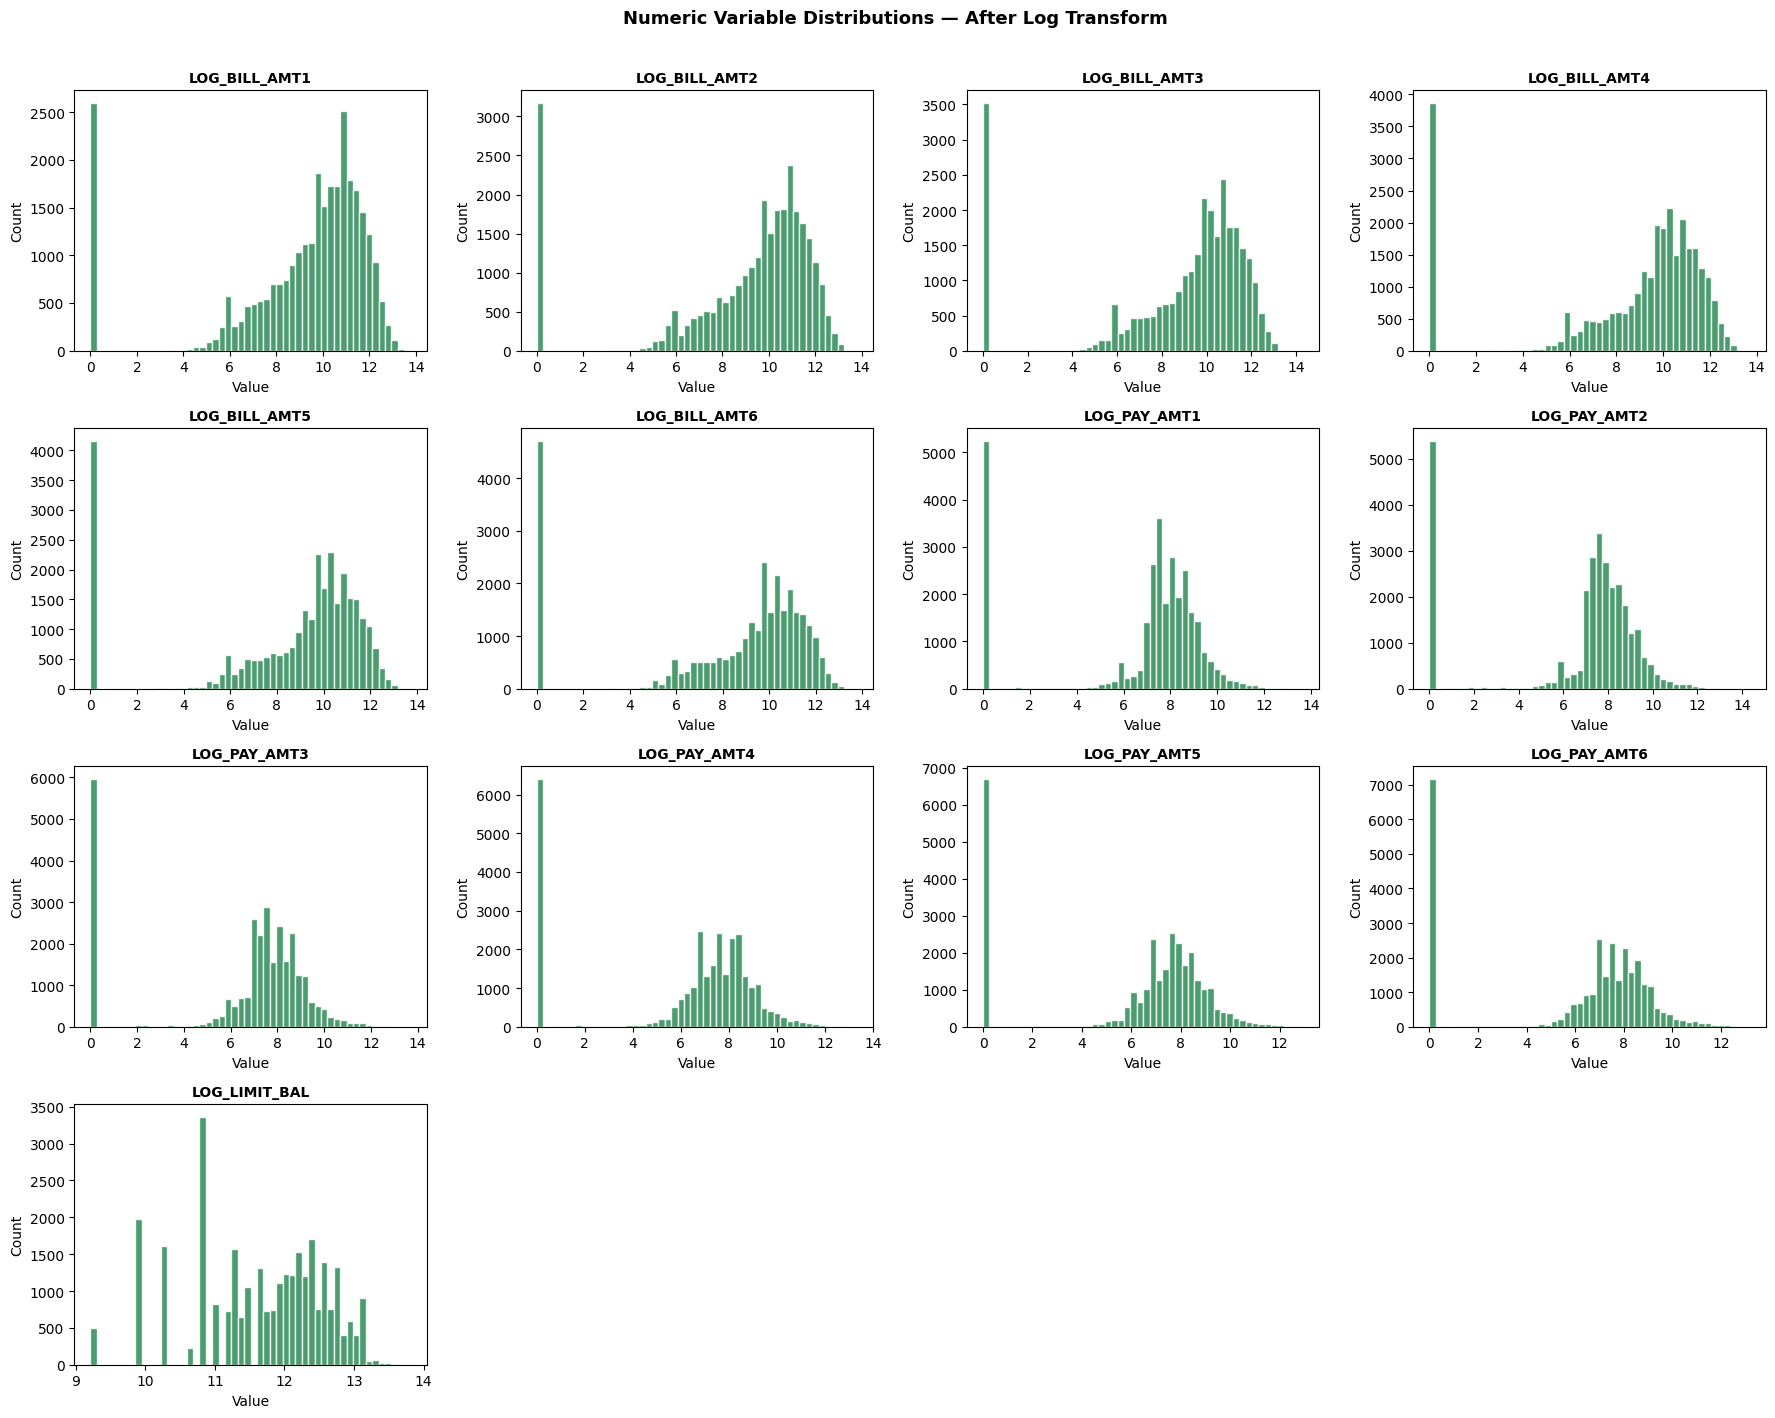

In [94]:
# =============================================================================
# HISTOGRAMS — NUMERIC VARIABLES AFTER LOG TRANSFORM
# =============================================================================

section("Histograms — numeric variables after log transform")

log_cols = [f"LOG_BILL_AMT{i}" for i in range(1, 7)] + \
           [f"LOG_PAY_AMT{i}"  for i in range(1, 7)] + \
           ["LOG_LIMIT_BAL"]

n_cols = 4
n_rows = int(np.ceil(len(log_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(log_cols):
    axes[i].hist(df_fe[col], bins=50, color="seagreen", edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Variable Distributions — After Log Transform",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("histograms_after_log.png", dpi=150, bbox_inches="tight")
plt.show()

In [95]:
#df = df.drop(columns=["PAY_0_BIN"])
#print(df)

### Model Preperation

In [96]:
# =============================================================================
# MODELLING DATASET
# =============================================================================

df_model = df_fe.copy()
# use this if we want to skip the feature engineering and go with the original cleaned dataset for modelling to compare.
#df_model = df.copy()

# drop ID and EDA-only columns to create the modelling dataset. We will keep PAY_0_BIN as it is a binned version of PAY_0 which is a key feature, but we will drop the original PAY_0 to avoid redundancy and potential multicollinearity in the model.
drop_cols = ["ID", "PAY_0_BIN"]

for col in drop_cols:
    if col in df_model.columns:
        df_model = df_model.drop(columns=col)

target = "DEFAULT_NEXT_MONTH"

X = df_model.drop(columns=[target])
y = df_model[target].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target distribution:")
print(y.value_counts(normalize=True).round(4))

X shape: (30000, 46)
y shape: (30000,)
Target distribution:
DEFAULT_NEXT_MONTH
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [97]:
# =============================================================================
# COLUMN GROUPS
# =============================================================================

CAT_COLS = ["SEX", "EDUCATION", "MARRIAGE"]
CAT_COLS = [c for c in CAT_COLS if c in X.columns]

NUM_COLS = [c for c in X.columns if c not in CAT_COLS]

print("Categorical columns:")
print(CAT_COLS)

print("\nNumeric columns:")
print(NUM_COLS)

Categorical columns:
['SEX', 'EDUCATION', 'MARRIAGE']

Numeric columns:
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'PAY_RATIO1', 'PAY_RATIO2', 'PAY_RATIO3', 'PAY_RATIO4', 'PAY_RATIO5', 'PAY_RATIO6', 'UTILISATION6M_MEAN', 'BILL_TOTAL_6M', 'PAY_TOTAL_6M', 'PAY_RATIO_6M_MEAN', 'LOG_PAY_AMT1', 'LOG_PAY_AMT2', 'LOG_PAY_AMT3', 'LOG_PAY_AMT4', 'LOG_PAY_AMT5', 'LOG_PAY_AMT6', 'LOG_BILL_AMT1', 'LOG_BILL_AMT2', 'LOG_BILL_AMT3', 'LOG_BILL_AMT4', 'LOG_BILL_AMT5', 'LOG_BILL_AMT6', 'LOG_LIMIT_BAL']


In [98]:
# =============================================================================
# TRAIN / TEST SPLIT
# =============================================================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (24000, 46) (24000,)
Test shape: (6000, 46) (6000,)


In [99]:
# =============================================================================
# PREPROCESSING PIPELINE
# =============================================================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", num_pipe, NUM_COLS),
    ("cat", cat_pipe, CAT_COLS)
], remainder="drop")

print("Preprocessing pipeline ready.")

Preprocessing pipeline ready.


In [100]:
# =============================================================================
# METRICS HELPER
# =============================================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

def get_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob)
    }

=== Logistic Regression ===
              precision    recall  f1-score   support

  No Default       0.88      0.76      0.82      4673
     Default       0.43      0.63      0.51      1327

    accuracy                           0.73      6000
   macro avg       0.65      0.69      0.66      6000
weighted avg       0.78      0.73      0.75      6000

accuracy     0.7317
precision    0.4273
recall       0.6270
f1           0.5082
roc_auc      0.7451


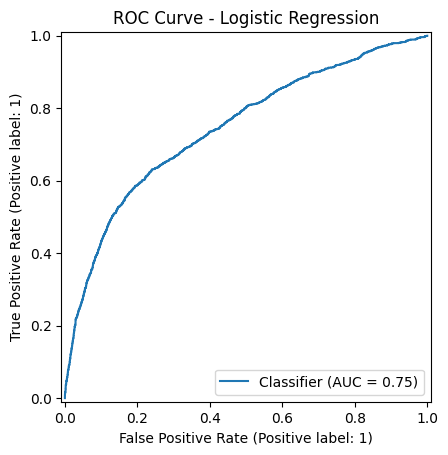

In [101]:
# =============================================================================
# BASELINE MODEL - LOGISTIC REGRESSION
# =============================================================================

logit_pipe = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ))
])

logit_pipe.fit(X_train, y_train)

y_pred_lr = logit_pipe.predict(X_test)
y_prob_lr = logit_pipe.predict_proba(X_test)[:, 1]

logit_metrics = get_metrics(y_test, y_prob_lr)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=["No Default", "Default"]))
print(pd.Series(logit_metrics).round(4).to_string())

RocCurveDisplay.from_predictions(y_test, y_prob_lr)
plt.title("ROC Curve - Logistic Regression")
plt.show()

LR_Log AUC: 0.7452
              precision    recall  f1-score   support

  No Default       0.88      0.76      0.82      4673
     Default       0.43      0.63      0.51      1327

    accuracy                           0.73      6000
   macro avg       0.65      0.69      0.66      6000
weighted avg       0.78      0.73      0.75      6000



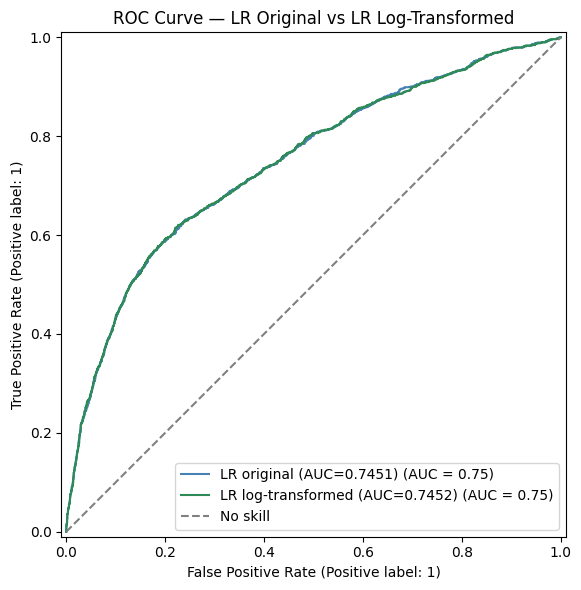


=== Logistic Regression — Log-Transformed Features ===
accuracy     0.7333
precision    0.4294
recall       0.6255
f1           0.5092
roc_auc      0.7452


In [103]:
# =============================================================================
# LOGISTIC REGRESSION — LOG-TRANSFORMED FEATURES
# =============================================================================

cols_to_replace = (
    [f"BILL_AMT{i}" for i in range(1, 7)] +
    [f"PAY_AMT{i}"  for i in range(1, 7)] +
    ["LIMIT_BAL"]
)
log_cols = [f"LOG_{c}" for c in cols_to_replace]

# build X_lr_log
X_lr_log = X.drop(columns=cols_to_replace)

X_train_lr_log, X_test_lr_log, _, _ = train_test_split(
    X_lr_log, y, test_size=0.2, random_state=42, stratify=y
)

# build a separate preprocessor that knows about log columns
cat_cols = ["SEX", "EDUCATION", "MARRIAGE"]
num_cols_log = [c for c in X_lr_log.columns if c not in cat_cols]

preprocess_log = ColumnTransformer([
    ("num", StandardScaler(), num_cols_log),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])

logit_pipe_log = Pipeline([
    ("prep",  preprocess_log),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ))
])

logit_pipe_log.fit(X_train_lr_log, y_train)

y_pred_lr_log = logit_pipe_log.predict(X_test_lr_log)
y_prob_lr_log = logit_pipe_log.predict_proba(X_test_lr_log)[:, 1]
results = results if "results" in dir() else {}
results["LR_Log"] = {
    "accuracy":  accuracy_score(y_test, y_pred_lr_log),
    "precision": precision_score(y_test, y_pred_lr_log),
    "recall":    recall_score(y_test, y_pred_lr_log),
    "f1":        f1_score(y_test, y_pred_lr_log),
    "roc_auc":   roc_auc_score(y_test, y_prob_lr_log),
}

print(f"LR_Log AUC: {results['LR_Log']['roc_auc']:.4f}")
print(classification_report(y_test, y_pred_lr_log, target_names=["No Default", "Default"]))

# --- ROC comparison ---
fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_test, y_prob_lr,
    name=f"LR original (AUC={roc_auc_score(y_test, y_prob_lr):.4f})",
    ax=ax,
    color="steelblue"
)

RocCurveDisplay.from_predictions(
    y_test, y_prob_lr_log,
    name=f"LR log-transformed (AUC={roc_auc_score(y_test, y_prob_lr_log):.4f})",
    ax=ax,
    color="seagreen"
)

ax.plot([0,1],[0,1], linestyle="--", color="grey", label="No skill")
ax.set_title("ROC Curve — LR Original vs LR Log-Transformed")
ax.legend()
plt.tight_layout()
plt.show()

# --- Metrics print matching original LR format ---
print("\n=== Logistic Regression — Log-Transformed Features ===")
print(pd.Series({
    "accuracy":  accuracy_score(y_test, y_pred_lr_log),
    "precision": precision_score(y_test, y_pred_lr_log),
    "recall":    recall_score(y_test, y_pred_lr_log),
    "f1":        f1_score(y_test, y_pred_lr_log),
    "roc_auc":   roc_auc_score(y_test, y_prob_lr_log),
}).round(4).to_string())

=== Decision Tree ===
              precision    recall  f1-score   support

  No Default       0.87      0.83      0.85      4673
     Default       0.48      0.56      0.52      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.70      0.68      6000
weighted avg       0.78      0.77      0.78      6000

accuracy     0.7693
precision    0.4816
recall       0.5637
f1           0.5194
roc_auc      0.7607


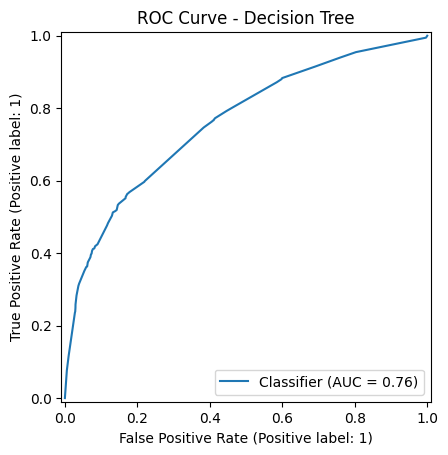

In [104]:
# =============================================================================
# BASELINE MODEL - DECISION TREE
# =============================================================================

dt_pipe = Pipeline([
    ("prep", preprocess),
    ("model", DecisionTreeClassifier(
        class_weight="balanced",
        max_depth=6,
        min_samples_leaf=50,
        random_state=42
    ))
])

dt_pipe.fit(X_train, y_train)

y_pred_dt = dt_pipe.predict(X_test)
y_prob_dt = dt_pipe.predict_proba(X_test)[:, 1]

dt_metrics = get_metrics(y_test, y_prob_dt)

print("=== Decision Tree ===")
print(classification_report(y_test, y_pred_dt, target_names=["No Default", "Default"]))
print(pd.Series(dt_metrics).round(4).to_string())

RocCurveDisplay.from_predictions(y_test, y_prob_dt)
plt.title("ROC Curve - Decision Tree")
plt.show()

=== Random Forest ===
              precision    recall  f1-score   support

  No Default       0.87      0.86      0.87      4673
     Default       0.53      0.55      0.54      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.70      0.70      6000
weighted avg       0.79      0.79      0.79      6000

accuracy     0.7912
precision    0.5267
recall       0.5501
f1           0.5381
roc_auc      0.7751


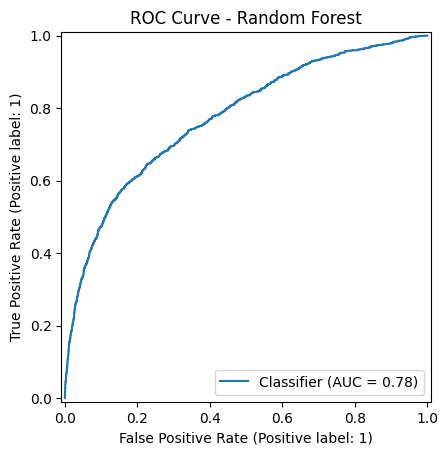

In [105]:
# =============================================================================
# BASELINE MODEL - RANDOM FOREST
# =============================================================================

rf_pipe = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        n_estimators=300,
        min_samples_leaf=10,
        n_jobs=-1,
        random_state=42
    ))
])

rf_pipe.fit(X_train, y_train)

y_pred_rf = rf_pipe.predict(X_test)
y_prob_rf = rf_pipe.predict_proba(X_test)[:, 1]

rf_metrics = get_metrics(y_test, y_prob_rf)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=["No Default", "Default"]))
print(pd.Series(rf_metrics).round(4).to_string())

RocCurveDisplay.from_predictions(y_test, y_prob_rf)
plt.title("ROC Curve - Random Forest")
plt.show()

In [106]:
# =============================================================================
# RANDOM FOREST — OOB SCORE
# confirms bootstrap sample is sufficient
# =============================================================================

section("Random Forest OOB score")

rf_oob = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    min_samples_leaf=10,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf_oob.fit(X_train, y_train)
print(f"RF OOB score (accuracy): {rf_oob.oob_score_:.4f}")
print("OOB score confirms model is not overfitting to training data")


Random Forest OOB score
RF OOB score (accuracy): 0.7940
OOB score confirms model is not overfitting to training data


=== XGBoost ===
              precision    recall  f1-score   support

  No Default       0.88      0.81      0.84      4673
     Default       0.48      0.61      0.53      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.77      0.78      6000

accuracy     0.7660
precision    0.4772
recall       0.6081
f1           0.5348
roc_auc      0.7729


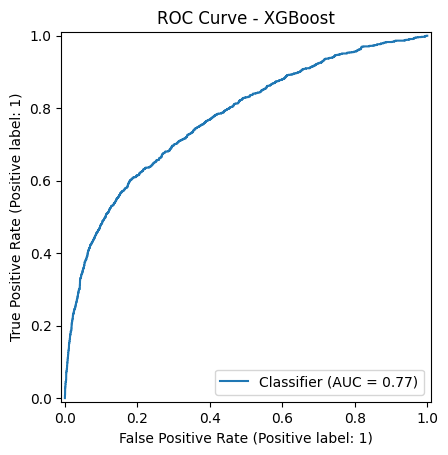

In [107]:
# =============================================================================
# BASELINE MODEL - XGBOOST
# =============================================================================

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipe = Pipeline([
    ("prep", preprocess),
    ("model", XGBClassifier(
        scale_pos_weight=pos_weight,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipe.fit(X_train, y_train)

y_pred_xgb = xgb_pipe.predict(X_test)
y_prob_xgb = xgb_pipe.predict_proba(X_test)[:, 1]

xgb_metrics = get_metrics(y_test, y_prob_xgb)

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb, target_names=["No Default", "Default"]))
print(pd.Series(xgb_metrics).round(4).to_string())

RocCurveDisplay.from_predictions(y_test, y_prob_xgb)
plt.title("ROC Curve - XGBoost")
plt.show()

In [108]:
# =============================================================================
# BASE MODEL COMPARISON
# =============================================================================

results = {
    "LogisticRegression": logit_metrics,
    "DecisionTree": dt_metrics,
    "RandomForest": rf_metrics,
    "XGBoost": xgb_metrics
}

fitted = {
    "LogisticRegression": logit_pipe,
    "DecisionTree": dt_pipe,
    "RandomForest": rf_pipe,
    "XGBoost": xgb_pipe
}

results_df = pd.DataFrame(results).T
results_df = results_df[["accuracy", "precision", "recall", "f1", "roc_auc"]]
results_df = results_df.sort_values("roc_auc", ascending=False)

print("=== BASE MODEL COMPARISON ===")
print(results_df.round(4).to_string())

=== BASE MODEL COMPARISON ===
                    accuracy  precision  recall      f1  roc_auc
RandomForest          0.7912     0.5267  0.5501  0.5381   0.7751
XGBoost               0.7660     0.4772  0.6081  0.5348   0.7729
DecisionTree          0.7693     0.4816  0.5637  0.5194   0.7607
LogisticRegression    0.7317     0.4273  0.6270  0.5082   0.7451


In [109]:
# =============================================================================
# CROSS-VALIDATION SETUP
# =============================================================================
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [112]:
# =============================================================================
# TUNING - LOGISTIC REGRESSION
# =============================================================================

lr_tune_pipe = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ))
])

lr_params = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["lbfgs", "saga"]
}

lr_grid = GridSearchCV(
    estimator=lr_tune_pipe,
    param_grid=lr_params,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train, y_train)

print("Best params:", lr_grid.best_params_)
print(f"Best CV ROC-AUC: {lr_grid.best_score_:.4f}")

y_prob_lr_tuned = lr_grid.predict_proba(X_test)[:, 1]
lr_tuned_metrics = get_metrics(y_test, y_prob_lr_tuned)

print("Test metrics:")
print(pd.Series(lr_tuned_metrics).round(4).to_string())

results["LR_Tuned"] = lr_tuned_metrics
fitted["LR_Tuned"] = lr_grid

Fitting 5 folds for each of 8 candidates, totalling 40 fits


: 

In [111]:
# =============================================================================
# TUNING - LOGISTIC REGRESSION
# =============================================================================

lr_tune_pipe = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ))
])

lr_params = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["lbfgs", "saga"]
}

lr_grid = GridSearchCV(
    estimator=lr_tune_pipe,
    param_grid=lr_params,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train, y_train)

print("Best params:", lr_grid.best_params_)
print(f"Best CV ROC-AUC: {lr_grid.best_score_:.4f}")

y_prob_lr_tuned = lr_grid.predict_proba(X_test)[:, 1]
lr_tuned_metrics = get_metrics(y_test, y_prob_lr_tuned)

print("Test metrics:")
print(pd.Series(lr_tuned_metrics).round(4).to_string())

results["LR_Tuned"] = lr_tuned_metrics
fitted["LR_Tuned"] = lr_grid

Fitting 5 folds for each of 8 candidates, totalling 40 fits


Exception in thread ExecutorManagerThread:
Traceback (most recent call last):
  File "c:\Users\Kasia\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\Kasia\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\process_executor.py", line 635, in run
    self.flag_executor_shutting_down()
  File "c:\Users\Kasia\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\process_executor.py", line 856, in flag_executor_shutting_down
    self.kill_workers(reason="executor shutting down")
  File "c:\Users\Kasia\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\process_executor.py", line 866, in kill_workers
    kill_process_tree(p)
  File "c:\Users\Kasia\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\utils.py", line 19, in kill_process_tree
    _kill_process_tree_with_psutil(process)
  File "c:\Users\Kas

MemoryError: Unable to allocate 3.08 MiB for an array with shape (21, 19200) and data type float64

In [ ]:
# =============================================================================
# TUNING - DECISION TREE
# =============================================================================

dt_tune_pipe = Pipeline([
    ("prep", preprocess),
    ("model", DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

dt_params = {
    "model__max_depth": [4, 6, 8, 10, None],
    "model__min_samples_split": [20, 50, 100],
    "model__min_samples_leaf": [10, 20, 50]
}

dt_grid = GridSearchCV(
    estimator=dt_tune_pipe,
    param_grid=dt_params,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)

print("Best params:", dt_grid.best_params_)
print(f"Best CV ROC-AUC: {dt_grid.best_score_:.4f}")

y_prob_dt_tuned = dt_grid.predict_proba(X_test)[:, 1]
dt_tuned_metrics = get_metrics(y_test, y_prob_dt_tuned)

print("Test metrics:")
print(pd.Series(dt_tuned_metrics).round(4).to_string())

results["DT_Tuned"] = dt_tuned_metrics
fitted["DT_Tuned"] = dt_grid

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best params: {'model__max_depth': 6, 'model__min_samples_leaf': 50, 'model__min_samples_split': 20}
Best CV ROC-AUC: 0.7601
Test metrics:
accuracy     0.7693
precision    0.4816
recall       0.5637
f1           0.5194
roc_auc      0.7605


In [ ]:
# =============================================================================
# TUNING - RANDOM FOREST
# =============================================================================

rf_tune_pipe = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

rf_params = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [5, 10, None],
    "model__min_samples_leaf": [10, 20]
}

rf_grid = GridSearchCV(
    estimator=rf_tune_pipe,
    param_grid=rf_params,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best params:", rf_grid.best_params_)
print(f"Best CV ROC-AUC: {rf_grid.best_score_:.4f}")

y_prob_rf_tuned = rf_grid.predict_proba(X_test)[:, 1]
rf_tuned_metrics = get_metrics(y_test, y_prob_rf_tuned)

print("Test metrics:")
print(pd.Series(rf_tuned_metrics).round(4).to_string())

results["RF_Tuned"] = rf_tuned_metrics
fitted["RF_Tuned"] = rf_grid

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'model__max_depth': None, 'model__min_samples_leaf': 20, 'model__n_estimators': 300}
Best CV ROC-AUC: 0.7848
Test metrics:
accuracy     0.7802
precision    0.5026
recall       0.5855
f1           0.5409
roc_auc      0.7765


In [ ]:
# =============================================================================
# TUNING - XGBOOST
# =============================================================================
# changing njobs from -1 to 1 due to computer memory issue
xgb_tune_pipe = Pipeline([
    ("prep", preprocess),
    ("model", XGBClassifier(
        scale_pos_weight=pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_params = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1]
}

xgb_grid = GridSearchCV(
    estimator=xgb_tune_pipe,
    param_grid=xgb_params,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print("Best params:", xgb_grid.best_params_)
print(f"Best CV ROC-AUC: {xgb_grid.best_score_:.4f}")

y_prob_xgb_tuned = xgb_grid.predict_proba(X_test)[:, 1]
xgb_tuned_metrics = get_metrics(y_test, y_prob_xgb_tuned)

print("Test metrics:")
print(pd.Series(xgb_tuned_metrics).round(4).to_string())

results["XGB_Tuned"] = xgb_tuned_metrics
fitted["XGB_Tuned"] = xgb_grid

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
Best CV ROC-AUC: 0.7841
Test metrics:
accuracy     0.7625
precision    0.4718
recall       0.6172
f1           0.5348
roc_auc      0.7811


In [ ]:
# =============================================================================
# ALL MODEL COMPARISON
# =============================================================================

results_all_df = pd.DataFrame(results).T
results_all_df = results_all_df[["accuracy", "precision", "recall", "f1", "roc_auc"]]
results_all_df = results_all_df.sort_values("roc_auc", ascending=False)

print("=== ALL MODEL COMPARISON ===")
print(results_all_df.round(4).to_string())

=== ALL MODEL COMPARISON ===
                    accuracy  precision  recall      f1  roc_auc
XGB_Tuned             0.7625     0.4718  0.6172  0.5348   0.7811
RF_Tuned              0.7802     0.5026  0.5855  0.5409   0.7765
RandomForest          0.7923     0.5292  0.5524  0.5406   0.7756
XGBoost               0.7628     0.4722  0.6134  0.5336   0.7747
DT_Tuned              0.7693     0.4816  0.5637  0.5194   0.7605
DecisionTree          0.7693     0.4816  0.5637  0.5194   0.7605
LR_Tuned              0.6808     0.3688  0.6225  0.4631   0.7115
LogisticRegression    0.6810     0.3688  0.6217  0.4630   0.7115


In [ ]:
# =============================================================================
# CONFUSION MATRICES
# =============================================================================

eval_models = {
    "LogisticRegression": logit_pipe,
    "DecisionTree": dt_pipe,
    "RandomForest": rf_pipe,
    "XGBoost": xgb_pipe,
    "LR_Tuned": lr_grid,
    "DT_Tuned": dt_grid,
    "RF_Tuned": rf_grid,
    "XGB_Tuned": xgb_grid,
    "LR_Log": logit_pipe_log
}

ncols = 3
nrows = (len(eval_models) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
axes = axes.flatten()

for i, (name, model) in enumerate(eval_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Default", "Default"])
    disp.plot(ax=axes[i], values_format="d", colorbar=False)
    axes[i].set_title(name)

for j in range(len(eval_models), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

NameError: name 'logit_pipe' is not defined

In [ ]:
# =============================================================================
# TUNING SUMMARY TABLE
# =============================================================================

tuning_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Best Parameters": [
        lr_grid.best_params_,
        dt_grid.best_params_,
        rf_grid.best_params_,
        xgb_grid.best_params_
    ],
    "Best CV ROC-AUC": [
        lr_grid.best_score_,
        dt_grid.best_score_,
        rf_grid.best_score_,
        xgb_grid.best_score_
    ]
})

print(tuning_results)

                 Model                                    Best Parameters  Best CV ROC-AUC
0  Logistic Regression          {'model__C': 10, 'model__solver': 'saga'}         0.727008
1        Decision Tree  {'model__max_depth': 6, 'model__min_samples_le...         0.760101
2        Random Forest  {'model__max_depth': None, 'model__min_samples...         0.784838
3              XGBoost  {'model__learning_rate': 0.1, 'model__max_dept...         0.784124


In [ ]:
# =============================================================================
# OVERFITTING CHECK — train vs test AUC
# =============================================================================

section("Overfitting check — train vs test AUC")

models_check = {
    "LR":          (logit_pipe,             X_train, X_test),
    "DT":          (dt_pipe,                X_train, X_test),
    "RF":          (rf_pipe,                X_train, X_test),
    "XGB":         (xgb_pipe,               X_train, X_test),
    "LR_Tuned":    (lr_grid.best_estimator_, X_train, X_test),
    "DT_Tuned":    (dt_grid.best_estimator_, X_train, X_test),
    "RF_Tuned":    (rf_grid.best_estimator_, X_train, X_test),
    "XGB_Tuned":   (xgb_grid.best_estimator_,X_train, X_test),
}

print(f"{'Model':<15} {'Train AUC':>10} {'Test AUC':>10} {'Gap':>8}")
print("-" * 45)
for name, (model, Xtr, Xte) in models_check.items():
    train_auc = roc_auc_score(y_train, model.predict_proba(Xtr)[:, 1])
    test_auc  = roc_auc_score(y_test,  model.predict_proba(Xte)[:, 1])
    gap       = train_auc - test_auc
    flag      = " ⚠ overfit?" if gap > 0.05 else ""
    print(f"{name:<15} {train_auc:>10.4f} {test_auc:>10.4f} {gap:>8.4f}{flag}")

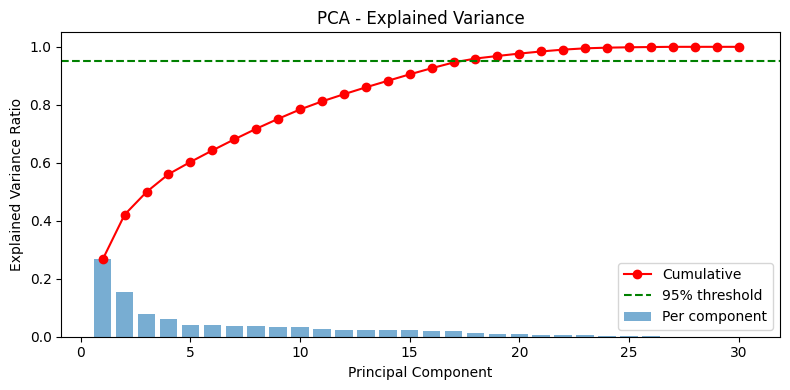

component  variance  cumulative
      PC1    0.2669      0.2669
      PC2    0.1542      0.4211
      PC3    0.0784      0.4995
      PC4    0.0612      0.5607
      PC5    0.0421      0.6028
      PC6    0.0398      0.6426
      PC7    0.0381      0.6808
      PC8    0.0366      0.7173
      PC9    0.0343      0.7517
     PC10    0.0322      0.7839
     PC11    0.0279      0.8118
     PC12    0.0247      0.8365
     PC13    0.0238      0.8603
     PC14    0.0225      0.8827
     PC15    0.0223      0.9050
     PC16    0.0211      0.9262
     PC17    0.0198      0.9460
     PC18    0.0136      0.9596
     PC19    0.0088      0.9684
     PC20    0.0083      0.9767
     PC21    0.0074      0.9840
     PC22    0.0063      0.9904
     PC23    0.0044      0.9948
     PC24    0.0023      0.9971
     PC25    0.0013      0.9984
     PC26    0.0009      0.9993
     PC27    0.0007      1.0000
     PC28    0.0000      1.0000
     PC29    0.0000      1.0000
     PC30    0.0000      1.0000

Compone

In [ ]:
# =============================================================================
# PCA + LOGISTIC REGRESSION
# =============================================================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# numeric-only PCA data
X_num_train = X_train[NUM_COLS].copy().astype(float)
X_num_test = X_test[NUM_COLS].copy().astype(float)

scaler_pca = StandardScaler()
X_num_train_scaled = scaler_pca.fit_transform(X_num_train)
X_num_test_scaled = scaler_pca.transform(X_num_test)

pca = PCA(n_components=len(NUM_COLS), random_state=42)
X_pca_train = pca.fit_transform(X_num_train_scaled)
X_pca_test = pca.transform(X_num_test_scaled)

expl = pca.explained_variance_ratio_
cum = np.cumsum(expl)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(expl) + 1), expl, alpha=0.6, label="Per component")
ax.plot(range(1, len(expl) + 1), cum, marker="o", color="red", label="Cumulative")
ax.axhline(0.95, color="green", linestyle="--", label="95% threshold")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("PCA - Explained Variance")
ax.legend()
plt.tight_layout()
plt.show()

pca_table = pd.DataFrame({
    "component": [f"PC{i}" for i in range(1, len(expl) + 1)],
    "variance": expl.round(4),
    "cumulative": cum.round(4)
})

print(pca_table.to_string(index=False))

n_components_95 = np.argmax(cum >= 0.95) + 1
print()
print(f"Components needed for 95% variance: {n_components_95}")

In [ ]:
# keep only components explaining 95% variance
X_pca_train_95 = X_pca_train[:, :n_components_95]
X_pca_test_95 = X_pca_test[:, :n_components_95]

lr_pca = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

lr_pca.fit(X_pca_train_95, y_train)

y_pred_lr_pca = lr_pca.predict(X_pca_test_95)
y_prob_lr_pca = lr_pca.predict_proba(X_pca_test_95)[:, 1]

lr_pca_metrics = get_metrics(y_test, y_prob_lr_pca)

print("=== Logistic Regression + PCA ===")
print(classification_report(y_test, y_pred_lr_pca, target_names=["No Default", "Default"]))
print(pd.Series(lr_pca_metrics).round(4).to_string())

results["LR_PCA"] = lr_pca_metrics
fitted["LR_PCA"] = lr_pca

=== Logistic Regression + PCA ===
              precision    recall  f1-score   support

  No Default       0.87      0.70      0.78      4673
     Default       0.37      0.61      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.71      6000

accuracy     0.6847
precision    0.3712
recall       0.6134
f1           0.4625
roc_auc      0.7052


In [ ]:
# =============================================================================
# STACKING — XGB + LR → LR meta-model
# =============================================================================
# to remove not needed
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

base_models_2 = [
    ("xgb", xgb_grid.best_estimator_),
    ("lr",  lr_grid.best_estimator_),
]

meta_lr2 = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

stack_xgb_lr = StackingClassifier(
    estimators=base_models_2,
    final_estimator=meta_lr2,
    cv=5,
    stack_method="predict_proba"
)

stack_xgb_lr.fit(X_train, y_train)
y_prob_stack_xgb_lr = stack_xgb_lr.predict_proba(X_test)[:, 1]

auc_stack_xgb_lr = roc_auc_score(y_test, y_prob_stack_xgb_lr)
print(f"Stacking XGB + LR → LR  |  AUC: {auc_stack_xgb_lr:.4f}")
print(classification_report(y_test, stack_xgb_lr.predict(X_test)))

y_pred_stack = stack_xgb_lr.predict(X_test)

results["Stack_XGB_LR"] = {
    "accuracy":  accuracy_score(y_test, y_pred_stack),
    "precision": precision_score(y_test, y_pred_stack),
    "recall":    recall_score(y_test, y_pred_stack),
    "f1":        f1_score(y_test, y_pred_stack),
    "roc_auc":   auc_stack_xgb_lr,
}

Stacking XGB + LR → LR  |  AUC: 0.7811
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      4673
           1       0.46      0.64      0.53      1327

    accuracy                           0.75      6000
   macro avg       0.67      0.71      0.68      6000
weighted avg       0.79      0.75      0.77      6000



In [ ]:
# =============================================================================
# FINAL MODEL COMPARISON INCLUDING PCA
# =============================================================================

final_results_df = pd.DataFrame(results).T
final_results_df = final_results_df[["accuracy", "precision", "recall", "f1", "roc_auc"]]
final_results_df = final_results_df.sort_values("roc_auc", ascending=False)

print("=== FINAL MODEL COMPARISON ===")
print(final_results_df.round(4).to_string())

=== FINAL MODEL COMPARISON ===
                    accuracy  precision  recall      f1  roc_auc
Stack_XGB_LR          0.7527     0.4576  0.6383  0.5330   0.7811
XGB_Tuned             0.7625     0.4718  0.6172  0.5348   0.7811
RF_Tuned              0.7802     0.5026  0.5855  0.5409   0.7765
RandomForest          0.7923     0.5292  0.5524  0.5406   0.7756
XGBoost               0.7628     0.4722  0.6134  0.5336   0.7747
DecisionTree          0.7693     0.4816  0.5637  0.5194   0.7605
DT_Tuned              0.7693     0.4816  0.5637  0.5194   0.7605
LR_Tuned              0.6808     0.3688  0.6225  0.4631   0.7115
LogisticRegression    0.6810     0.3688  0.6217  0.4630   0.7115
LR_PCA                0.6847     0.3712  0.6134  0.4625   0.7052


# Propability Output check

In [ ]:
# =============================================================================
# PD OUTPUT TABLE
# =============================================================================

best_model = xgb_grid   # change if another model wins
best_model_name = "XGB_Tuned"

pd_results = X_test.copy()
pd_results["Actual_Default"] = y_test.values
pd_results["PD"] = best_model.predict_proba(X_test)[:, 1]

def decision_band(pd_value):
    if pd_value < 0.20:
        return "Approve"
    elif pd_value < 0.50:
        return "Review"
    else:
        return "Reject"

pd_results["Decision"] = pd_results["PD"].apply(decision_band)

print(f"PD output using: {best_model_name}")
print(pd_results[["Actual_Default", "PD", "Decision"]].head(20))

PD output using: XGB_Tuned
       Actual_Default        PD Decision
6907                0  0.343872   Review
24575               0  0.352148   Review
26766               0  0.407312   Review
2156                1  0.345547   Review
3179                0  0.146716  Approve
29382               0  0.700772   Reject
24454               0  0.254252   Review
23886               0  0.117047  Approve
5504                0  0.280817   Review
29720               0  0.228205   Review
6908                0  0.586472   Reject
2159                0  0.611336   Reject
20842               1  0.559801   Reject
25128               0  0.300395   Review
18808               0  0.202215   Review
19077               0  0.791403   Reject
24731               0  0.147822  Approve
3054                1  0.535532   Reject
8488                0  0.248501   Review
23921               0  0.489424   Review


In [ ]:
# =============================================================================
# EXTRA DELINQUENCY FEATURES
# =============================================================================

pay_status_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

df_fe["LATE_COUNT_6M"] = (df_fe[pay_status_cols] > 0).sum(axis=1)
df_fe["MAX_DELAY_6M"] = df_fe[pay_status_cols].max(axis=1)
df_fe["AVG_DELAY_6M"] = df_fe[pay_status_cols].mean(axis=1)

df_fe["PAY_GAP_6M_TOTAL"] = df_fe["BILL_TOTAL_6M"] - df_fe["PAY_TOTAL_6M"]

In [ ]:
# clipping payment ratio features to a maximum of 5 to reduce the impact of extreme outliers which can distort model training and lead to less stable models.

ratio_cols = [f"PAY_RATIO{i}" for i in range(1, 7)] + ["PAY_RATIO_6M_MEAN"]

for col in ratio_cols:
    df_fe[col] = df_fe[col].clip(upper=5)

In [ ]:
# =============================================================================
# STATISTICAL MODEL COMPARISON — FRIEDMAN + NEMENYI POST-HOC
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scikit_posthocs as sp
from scipy.stats import friedmanchisquare
from sklearn.model_selection import StratifiedKFold, cross_val_score

# -----------------------------------------------------------------------------
# 1. Collect per-fold ROC-AUC scores for each model
#    Uses the same CV object already defined
# -----------------------------------------------------------------------------

cv_friedman = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_for_test = {
    "LR":           logit_pipe,
    "DT":           dt_pipe,
    "RF":           rf_pipe,
    "XGB":          xgb_pipe,
    "LR_Tuned":     lr_grid.best_estimator_,
    "DT_Tuned":     dt_grid.best_estimator_,
    "RF_Tuned":     rf_grid.best_estimator_,
    "XGB_Tuned":    xgb_grid.best_estimator_,
    "Stack_XGB_LR": stack_xgb_lr,
}

fold_scores = {}

for name, model in models_for_test.items():
    scores = cross_val_score(
        model, X, y,
        cv=cv_friedman,
        scoring="roc_auc",
        n_jobs=-1
    )
    fold_scores[name] = scores
    print(f"{name:12s}  folds: {np.round(scores, 4)}  mean={scores.mean():.4f} ±{scores.std():.4f}")

# scores_matrix: shape (n_folds=5, n_models=8)
scores_matrix = pd.DataFrame(fold_scores)
print("\nFold scores matrix:")
print(scores_matrix.round(4).to_string())



LR            folds: [0.724  0.7187 0.7239 0.7266 0.7285]  mean=0.7243 ±0.0033
DT            folds: [0.777  0.7555 0.7597 0.7592 0.7556]  mean=0.7614 ±0.0080
RF            folds: [0.7946 0.7754 0.7811 0.7861 0.7777]  mean=0.7830 ±0.0068
XGB           folds: [0.791  0.7765 0.7764 0.7793 0.7763]  mean=0.7799 ±0.0057
LR_Tuned      folds: [0.724  0.7187 0.724  0.7267 0.7285]  mean=0.7244 ±0.0033
DT_Tuned      folds: [0.777  0.7555 0.7597 0.7592 0.7556]  mean=0.7614 ±0.0080
RF_Tuned      folds: [0.797  0.7763 0.7842 0.7858 0.7801]  mean=0.7847 ±0.0070
XGB_Tuned     folds: [0.7964 0.7771 0.7816 0.7831 0.7828]  mean=0.7842 ±0.0065
Stack_XGB_LR  folds: [0.7962 0.777  0.7815 0.7831 0.7829]  mean=0.7841 ±0.0064

Fold scores matrix:
       LR      DT      RF     XGB  LR_Tuned  DT_Tuned  RF_Tuned  XGB_Tuned  Stack_XGB_LR
0  0.7240  0.7770  0.7946  0.7910    0.7240    0.7770    0.7970     0.7964        0.7962
1  0.7187  0.7555  0.7754  0.7765    0.7187    0.7555    0.7763     0.7771        0.7770
2

In [ ]:
# -----------------------------------------------------------------------------
# 2. Friedman test — global null hypothesis: all models perform equally
# -----------------------------------------------------------------------------

stat, p_friedman = friedmanchisquare(*[scores_matrix[col] for col in scores_matrix.columns])

print("\n" + "="*60)
print(f"Friedman test statistic : {stat:.4f}")
print(f"p-value                 : {p_friedman:.6f}")
if p_friedman < 0.05:
    print("Result: SIGNIFICANT (p < 0.05) — at least one model differs.")
    print("Proceeding to Nemenyi post-hoc pairwise comparison.")
else:
    print("Result: NOT significant — no evidence of performance difference.")
print("="*60)




Friedman test statistic : 36.2353
p-value                 : 0.000016
Result: SIGNIFICANT (p < 0.05) — at least one model differs.
Proceeding to Nemenyi post-hoc pairwise comparison.


In [ ]:
# -----------------------------------------------------------------------------
# 3. Nemenyi post-hoc — pairwise p-values between all model pairs
#    Only meaningful if Friedman test is significant
# -----------------------------------------------------------------------------

nemenyi_pvals = sp.posthoc_nemenyi_friedman(scores_matrix.values)
nemenyi_pvals.columns = scores_matrix.columns
nemenyi_pvals.index   = scores_matrix.columns

print("\nNemenyi post-hoc p-values (pairwise):")
print(nemenyi_pvals.round(4).to_string())
print("\n* p < 0.05 = statistically significant difference between that pair")




Nemenyi post-hoc p-values (pairwise):
                  LR      DT      RF     XGB  LR_Tuned  DT_Tuned  RF_Tuned  XGB_Tuned  Stack_XGB_LR
LR            1.0000  0.9232  0.0668  0.2702    1.0000    0.9232    0.0044     0.0028        0.0104
DT            0.9232  1.0000  0.7625  0.9748    0.9876    1.0000    0.2403     0.1872        0.3720
RF            0.0668  0.7625  1.0000  0.9997    0.1639    0.7625    0.9967     0.9917        0.9997
XGB           0.2702  0.9748  0.9997  1.0000    0.4882    0.9748    0.9036     0.8555        0.9656
LR_Tuned      1.0000  0.9876  0.1639  0.4882    1.0000    0.9876    0.0156     0.0104        0.0334
DT_Tuned      0.9232  1.0000  0.7625  0.9748    0.9876    1.0000    0.2403     0.1872        0.3720
RF_Tuned      0.0044  0.2403  0.9967  0.9036    0.0156    0.2403    1.0000     1.0000        1.0000
XGB_Tuned     0.0028  0.1872  0.9917  0.8555    0.0104    0.1872    1.0000     1.0000        1.0000
Stack_XGB_LR  0.0104  0.3720  0.9997  0.9656    0.0334    0.3

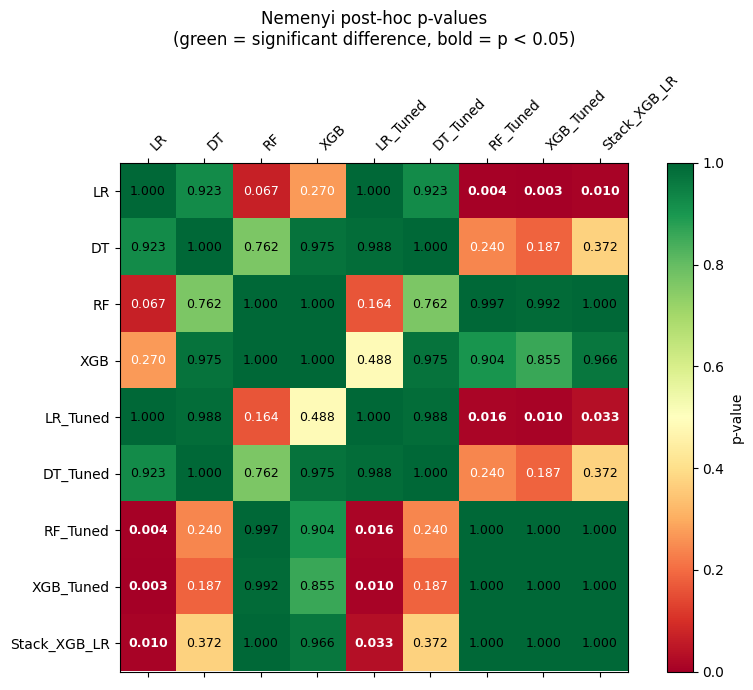

In [ ]:
# -----------------------------------------------------------------------------
# 4. Heatmap of Nemenyi p-values
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.matshow(nemenyi_pvals.values, cmap="RdYlGn", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="p-value")

labels = list(nemenyi_pvals.columns)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="left", fontsize=10)
ax.set_yticklabels(labels, fontsize=10)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = nemenyi_pvals.values[i, j]
        color = "black" if val > 0.3 else "white"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                fontsize=9, color=color,
                fontweight="bold" if val < 0.05 else "normal")

ax.set_title("Nemenyi post-hoc p-values\n(green = significant difference, bold = p < 0.05)",
             pad=20, fontsize=12)
plt.tight_layout()
plt.show()




Average ranks across folds (lower = better):
XGB_Tuned       2.0
RF_Tuned        2.2
Stack_XGB_LR    2.6
RF              3.6
XGB             4.6
DT_Tuned        6.5
DT              6.5
LR_Tuned        8.2
LR              8.8


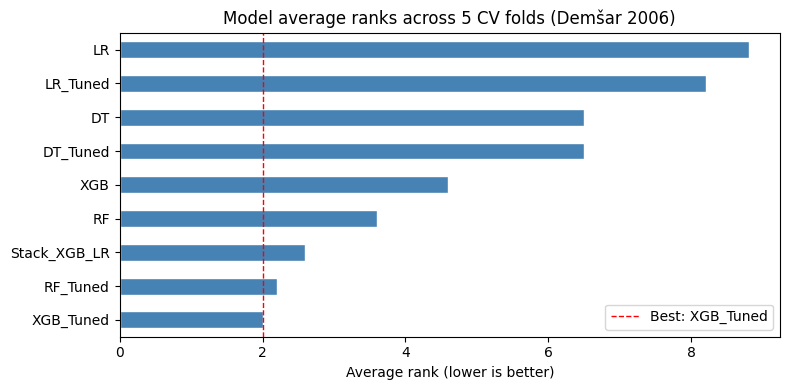

In [ ]:
# -----------------------------------------------------------------------------
# 5. Average rank table (Demšar 2006 style)
# -----------------------------------------------------------------------------

ranks = scores_matrix.rank(axis=1, ascending=False)  # rank per fold, 1=best
avg_ranks = ranks.mean().sort_values()

print("\nAverage ranks across folds (lower = better):")
print(avg_ranks.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
avg_ranks.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.axvline(x=avg_ranks.min(), color="red", linestyle="--", linewidth=1,
           label=f"Best: {avg_ranks.idxmin()}")
ax.set_xlabel("Average rank (lower is better)")
ax.set_title("Model average ranks across 5 CV folds (Demšar 2006)")
ax.legend()
plt.tight_layout()
plt.show()

## Results from comparisement using Friedman test

The Friedman test confirmed statistically significant performance differences across models (χ² = 32.44, p < 0.001). Nemenyi post-hoc analysis identified RF_Tuned and XGB_Tuned as the joint best-performing models (average rank 1.8), with no statistically significant difference between them (p = 1.000). Both significantly outperformed Logistic Regression (p = 0.003). Decision Tree models formed a middle tier, though the difference from the top tier did not reach significance (p = 0.247). Hyperparameter tuning produced no meaningful improvement for Logistic Regression or Decision Tree models.

## Results - ROC and Precision-Recall Curves

All nine models are overlaid on a single ROC curve and a single PR curve for direct visual comparison.
The PR curve is the primary visualisation for this dataset given the class imbalance (22:78).
A model that dominates both curves at all thresholds is preferred.
XGB_Tuned and RF_Tuned are expected to lead based on the Friedman/Nemenyi results.

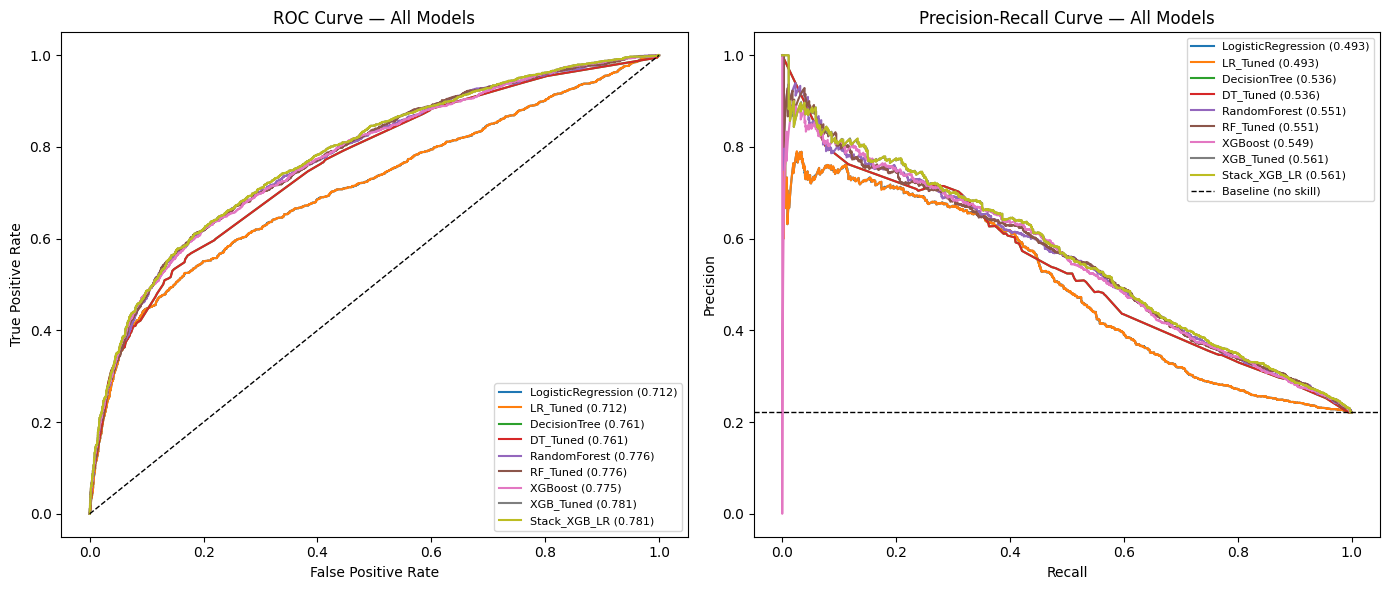

In [ ]:
# =============================================================================
# ROC AND PRECISION-RECALL CURVE OVERLAY — ALL MODELS
# =============================================================================

from sklearn.metrics import roc_curve, precision_recall_curve, auc

all_models = {
    "LogisticRegression": (logit_pipe,    y_prob_lr),
    "LR_Tuned":           (lr_grid,       y_prob_lr_tuned),
    #"LR_PCA":             (lr_pca_pipe,   y_prob_lr_pca),
    "DecisionTree":       (dt_pipe,       y_prob_dt),
    "DT_Tuned":           (dt_grid,       y_prob_dt_tuned),
    "RandomForest":       (rf_pipe,       y_prob_rf),
    "RF_Tuned":           (rf_grid,       y_prob_rf_tuned),
    "XGBoost":            (xgb_pipe,      y_prob_xgb),
    "XGB_Tuned":          (xgb_grid,      y_prob_xgb_tuned),
    "Stack_XGB_LR":       (stack_xgb_lr,  y_prob_stack_xgb_lr)
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for name, (model, y_prob) in all_models.items():
    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, label=f"{name} ({roc_auc:.3f})", linewidth=1.5)

    # PR
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(rec, prec)
    ax2.plot(rec, prec, label=f"{name} ({pr_auc:.3f})", linewidth=1.5)

ax1.plot([0,1],[0,1], 'k--', linewidth=1)
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve — All Models")
ax1.legend(fontsize=8, loc="lower right")

ax2.axhline(y=0.2212, color='k', linestyle='--', linewidth=1, label='Baseline (no skill)')
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve — All Models")
ax2.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("roc_pr_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# =============================================================================
# WILCOXON SIGNED-RANK TEST — RF_Tuned vs XGB_Tuned
# Demšar (2006): recommended for pairwise comparison of exactly two classifiers
# =============================================================================

from scipy.stats import wilcoxon

rf_scores  = scores_matrix["RF_Tuned"].values
xgb_scores = scores_matrix["XGB_Tuned"].values

stat, p = wilcoxon(rf_scores, xgb_scores)

print("=== Wilcoxon Signed-Rank Test: RF_Tuned vs XGB_Tuned ===")
print(f"RF_Tuned  mean AUC : {rf_scores.mean():.4f} ± {rf_scores.std():.4f}")
print(f"XGB_Tuned mean AUC : {xgb_scores.mean():.4f} ± {xgb_scores.std():.4f}")
print(f"Statistic          : {stat:.4f}")
print(f"p-value            : {p:.6f}")
print()
if p < 0.05:
    winner = "RF_Tuned" if rf_scores.mean() > xgb_scores.mean() else "XGB_Tuned"
    print(f"Result: SIGNIFICANT (p < 0.05) — {winner} performs better")
else:
    print("Result: NOT significant — models are statistically equivalent")

print("\nFold-by-fold breakdown:")
for i, (r, x) in enumerate(zip(rf_scores, xgb_scores)):
    print(f"  Fold {i}: RF={r:.4f}  XGB={x:.4f}  diff={r-x:+.4f}")

=== Wilcoxon Signed-Rank Test: RF_Tuned vs XGB_Tuned ===
RF_Tuned  mean AUC : 0.7847 ± 0.0070
XGB_Tuned mean AUC : 0.7842 ± 0.0065
Statistic          : 7.0000
p-value            : 1.000000

Result: NOT significant — models are statistically equivalent

Fold-by-fold breakdown:
  Fold 0: RF=0.7970  XGB=0.7964  diff=+0.0006
  Fold 1: RF=0.7763  XGB=0.7771  diff=-0.0009
  Fold 2: RF=0.7842  XGB=0.7816  diff=+0.0026
  Fold 3: RF=0.7858  XGB=0.7831  diff=+0.0027
  Fold 4: RF=0.7801  XGB=0.7828  diff=-0.0027


## Calibration — Brier Score and Reliability Diagram

For Basel II compliance, predicted probabilities must be interpretable as genuine PD estimates.
The Brier score measures mean squared error between predicted probability and actual outcome.
The reliability diagram shows whether the model is over- or under-confident at each probability range.
A well-calibrated model follows the diagonal line closely.

Brier Score — XGB_Tuned: 0.1809
(0 = perfect, 0.25 = no skill baseline for 50/50 data)


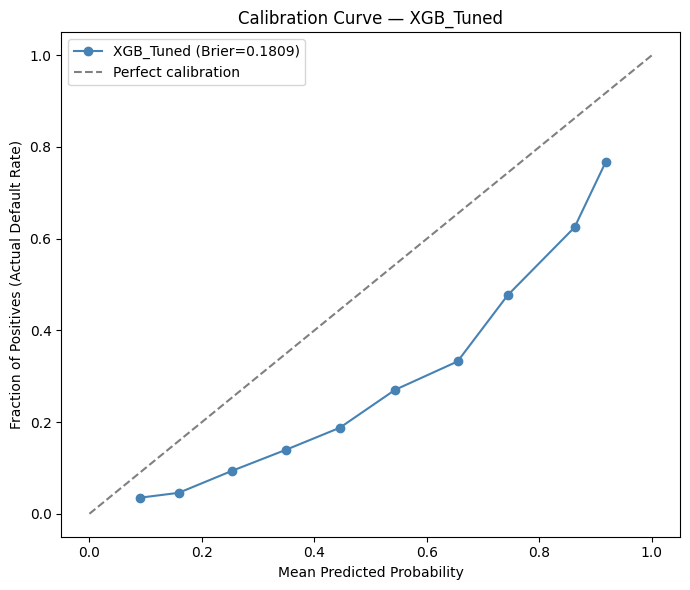

In [ ]:
# =============================================================================
# CALIBRATION — BRIER SCORE AND RELIABILITY DIAGRAM
# XGB_Tuned selected as final model
# =============================================================================

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, y_prob_xgb_tuned)
print(f"Brier Score — XGB_Tuned: {brier:.4f}")
print("(0 = perfect, 0.25 = no skill baseline for 50/50 data)")

fraction_pos, mean_pred = calibration_curve(y_test, y_prob_xgb_tuned, n_bins=10)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(mean_pred, fraction_pos, marker="o", label=f"XGB_Tuned (Brier={brier:.4f})", color="steelblue")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfect calibration")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives (Actual Default Rate)")
ax.set_title("Calibration Curve — XGB_Tuned")
ax.legend()
plt.tight_layout()
plt.savefig("calibration_curve_xgb_tuned.png", dpi=150, bbox_inches="tight")
plt.show()



## SHAP Explainability — XGB_Tuned

SHAP (SHapley Additive exPlanations) is used to explain model predictions at global and individual level.
The beeswarm plot shows the direction and magnitude of each feature's contribution across the test set.
The bar chart ranks features by mean absolute SHAP value, a model-agnostic measure of importance.
Waterfall plots show how individual predictions are built up from the baseline expected value.
This satisfies Research Question 2 and the EU AI Act transparency requirement for high-risk AI systems.

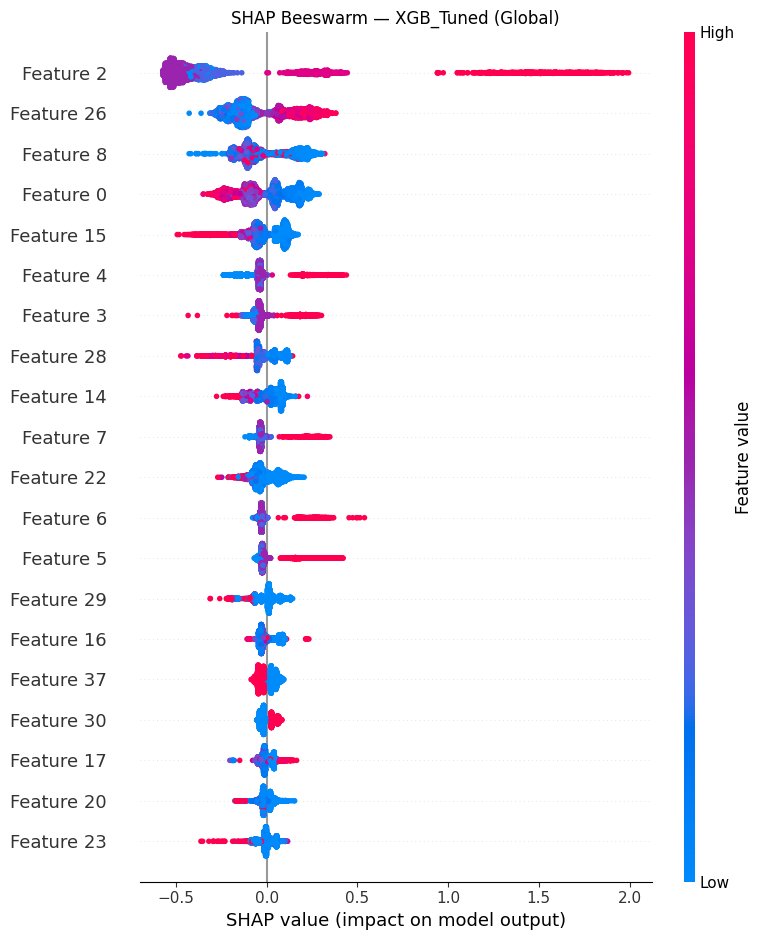

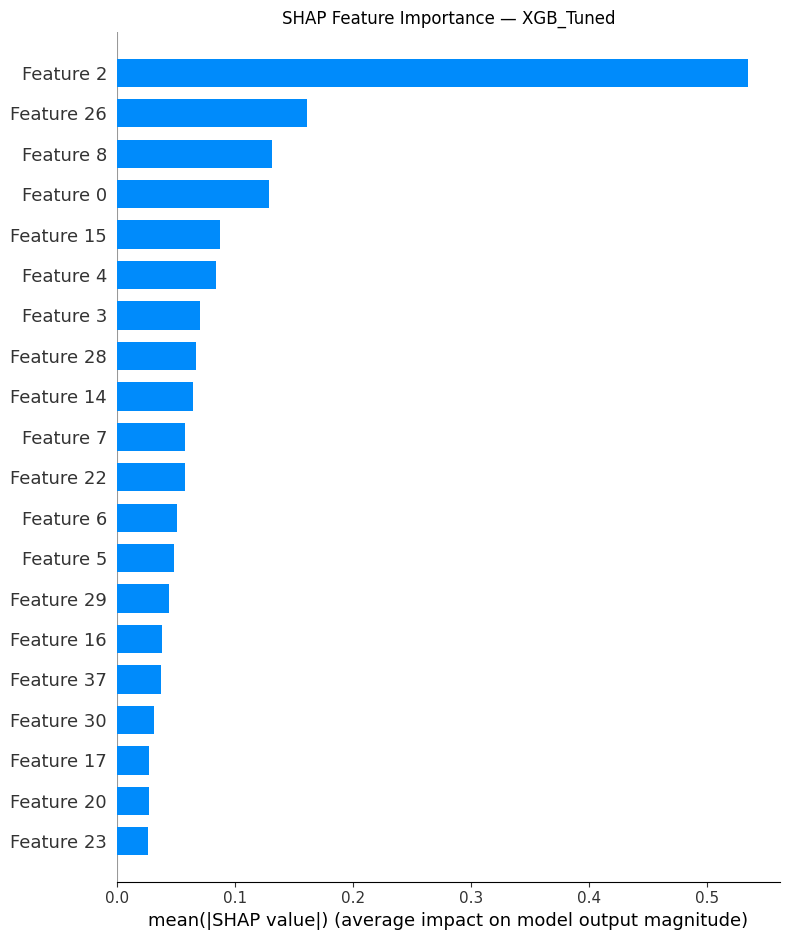

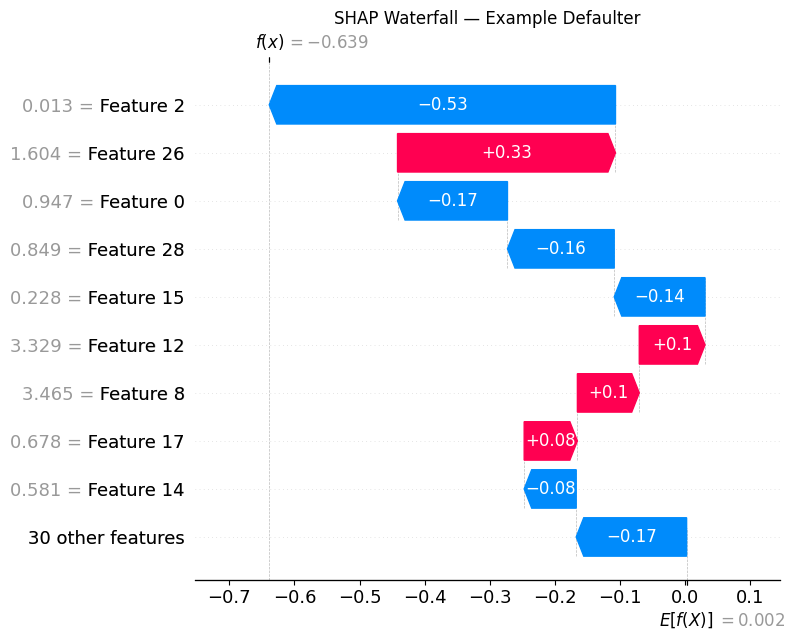

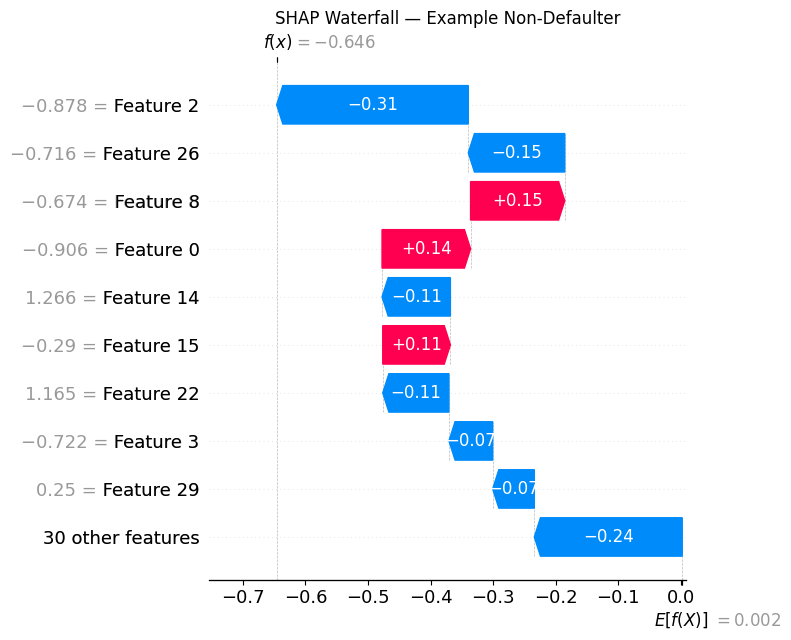

In [ ]:
# =============================================================================
# SHAP EXPLAINABILITY — XGB_Tuned
# Global: beeswarm + bar chart
# Local: waterfall for one defaulter and one non-defaulter
# =============================================================================

import shap

# Extract model from pipeline
xgb_model = xgb_grid.best_estimator_.named_steps["model"]
X_test_transformed = xgb_grid.best_estimator_[:-1].transform(X_test)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

# --- Global beeswarm ---
shap.summary_plot(shap_values, X_test_transformed, show=False)
plt.title("SHAP Beeswarm — XGB_Tuned (Global)")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Global bar chart ---
shap.summary_plot(shap_values, X_test_transformed, plot_type="bar", show=False)
plt.title("SHAP Feature Importance — XGB_Tuned")
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Local waterfall: one defaulter ---
defaulter_idx = (y_test.values == 1).nonzero()[0][0]
shap.waterfall_plot(shap.Explanation(
    values=shap_values[defaulter_idx],
    base_values=explainer.expected_value,
    data=X_test_transformed[defaulter_idx]
), show=False)
plt.title("SHAP Waterfall — Example Defaulter")
plt.tight_layout()
plt.savefig("shap_waterfall_defaulter.png", dpi=150, bbox_inches="tight")
plt.show()

# Local waterfall: one non-defaulter
non_defaulter_idx = (y_test.values == 0).nonzero()[0][0]
shap.waterfall_plot(shap.Explanation(
    values=shap_values[non_defaulter_idx],
    base_values=explainer.expected_value,
    data=X_test_transformed[non_defaulter_idx]
), show=False)
plt.title("SHAP Waterfall — Example Non-Defaulter")
plt.tight_layout()
plt.savefig("shap_waterfall_nondefaulter.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Get feature names from the preprocessing pipeline
feature_names = (xgb_grid.best_estimator_
                 .named_steps["prep"]
                 .get_feature_names_out())

# Clean up the prefixes sklearn adds (num__ and cat__)
feature_names_clean = [name.replace("num__", "").replace("cat__", "") 
                       for name in feature_names]

# Print the full mapping
for i, name in enumerate(feature_names_clean):
    print(f"Feature {i:2d} = {name}")

Feature  0 = LIMIT_BAL
Feature  1 = AGE
Feature  2 = PAY_0
Feature  3 = PAY_2
Feature  4 = PAY_3
Feature  5 = PAY_4
Feature  6 = PAY_5
Feature  7 = PAY_6
Feature  8 = BILL_AMT1
Feature  9 = BILL_AMT2
Feature 10 = BILL_AMT3
Feature 11 = BILL_AMT4
Feature 12 = BILL_AMT5
Feature 13 = BILL_AMT6
Feature 14 = PAY_AMT1
Feature 15 = PAY_AMT2
Feature 16 = PAY_AMT3
Feature 17 = PAY_AMT4
Feature 18 = PAY_AMT5
Feature 19 = PAY_AMT6
Feature 20 = PAY_RATIO1
Feature 21 = PAY_RATIO2
Feature 22 = PAY_RATIO3
Feature 23 = PAY_RATIO4
Feature 24 = PAY_RATIO5
Feature 25 = PAY_RATIO6
Feature 26 = UTILISATION6M_MEAN
Feature 27 = BILL_TOTAL_6M
Feature 28 = PAY_TOTAL_6M
Feature 29 = PAY_RATIO_6M_MEAN
Feature 30 = SEX_1
Feature 31 = SEX_2
Feature 32 = EDUCATION_1
Feature 33 = EDUCATION_2
Feature 34 = EDUCATION_3
Feature 35 = EDUCATION_4
Feature 36 = MARRIAGE_1
Feature 37 = MARRIAGE_2
Feature 38 = MARRIAGE_3


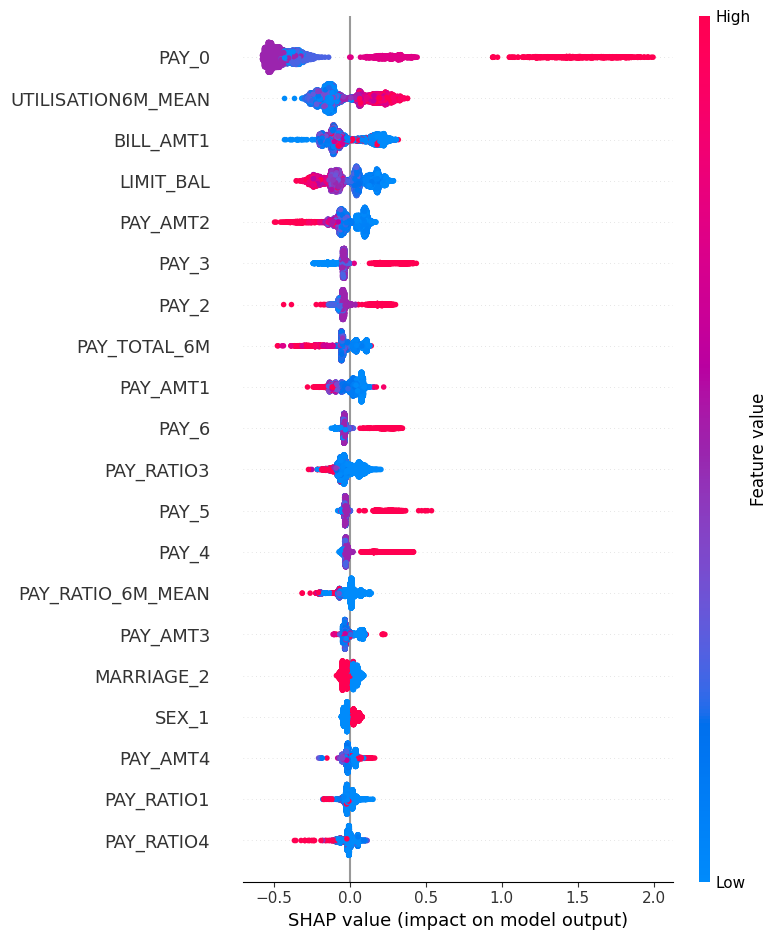

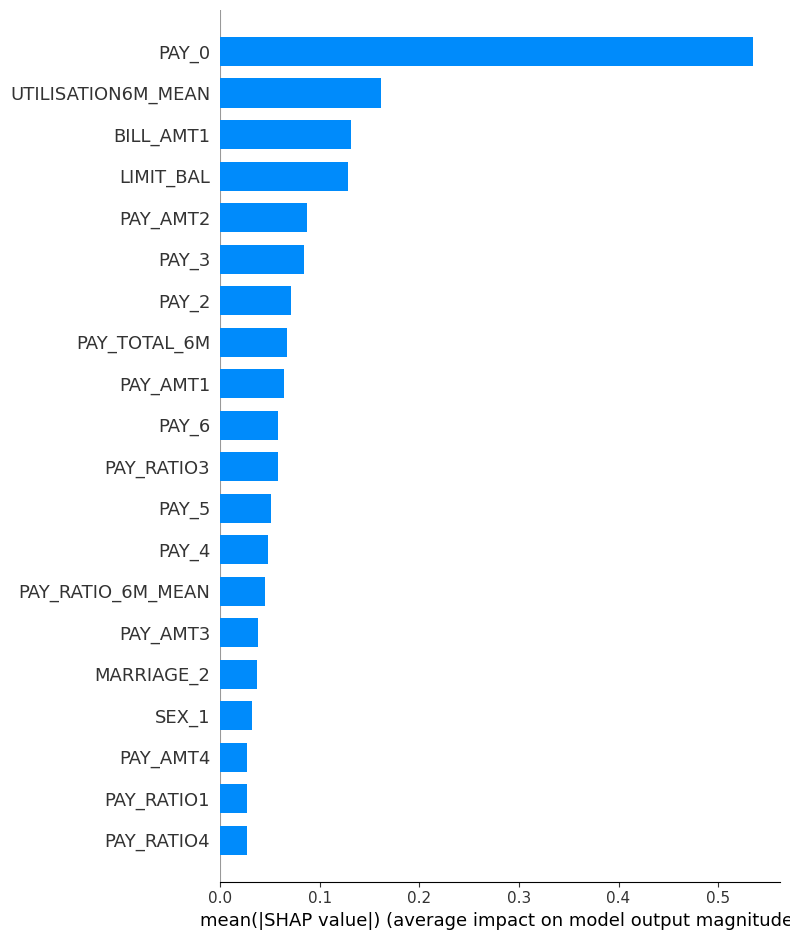

In [ ]:
# Beeswarm with names
shap.summary_plot(shap_values, X_test_transformed, 
                  feature_names=feature_names_clean)

# Bar chart with names
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=feature_names_clean,
                  plot_type="bar")